In [9]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from scipy.stats import spearmanr, kruskal
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv('drug200.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


In [11]:
df.head()

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,drugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,drugY


ticker 
date	
price_before - стоимость портфеля в начале эксперимента
price_after - стоимость портфеля в после эксперимента
volume_before 
volume_after	
strategy_version	
market_condition - состояние рынка, растущий или падающий  	
return_before	
return_after	
target

In [12]:
df.isnull().sum().sum()

np.int64(0)

In [13]:
df.duplicated().any() 

np.False_

<Axes: ylabel='Na_to_K'>

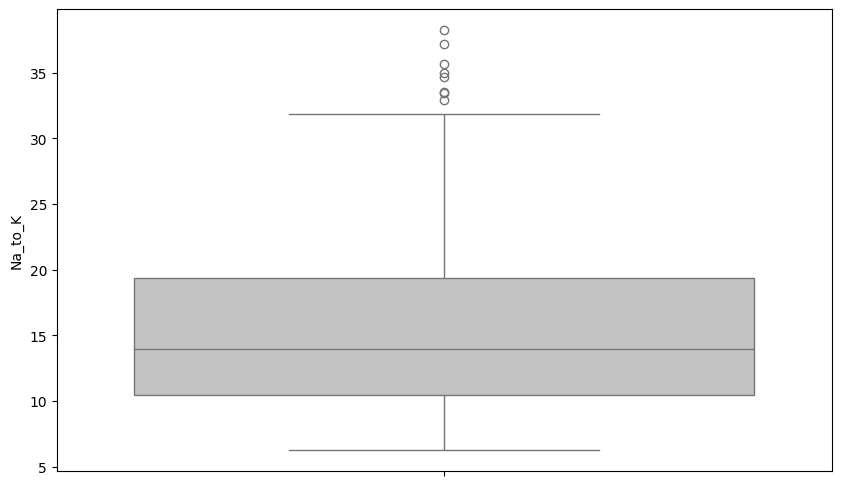

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    df['Na_to_K'], color='#C3C3C3'
)

Хуево, 9 значений

<Axes: ylabel='Age'>

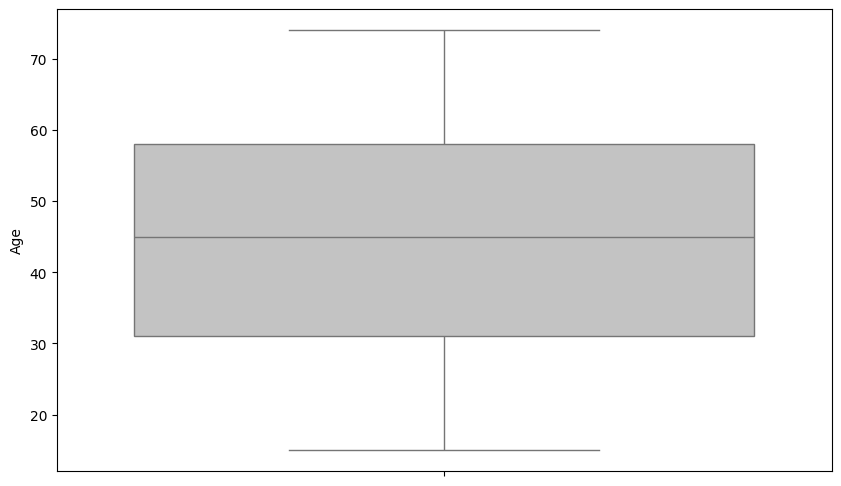

In [15]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    df['Age'], color='#C3C3C3'
)

Аномальных лет нет

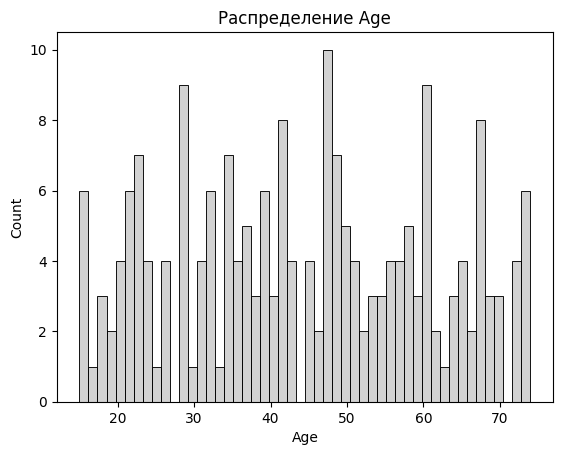

In [16]:
sns.histplot(
    df['Age'],
    bins = 50, color='#C3C3C3'
    #bins=50,
)
plt.title('Распределение Age')
plt.show()

In [17]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


среднее близко к 50% процентилю, возможно выбросы не так страшны. 200 данных может быть маловато, проверю хватит ли выборки и нужно ли синтетически увеличивать. Но скорее всего будет бустреп

In [30]:
σ = 7.23  # std из твоих данных
Z = 1.96
E = 1     # Теперь правильная погрешность

n = (Z * σ / E) ** 2
print(f"n = ({Z} × {σ} / {E})² = {n:.1f} ≈ {math.ceil(n)}")

n = (1.96 × 7.23 / 1)² = 200.8 ≈ 201


Ну да.

In [19]:
print('Стандартное отклонение', std)

Стандартное отклонение 7.223955528459516


В целом не очень, $$ \frac{38}{7.2}= 5.27$$  маловатое в рамках максимального различие 

In [20]:
# Для BP
categories_bp = {
    "LOW": 64/200,
    "NORMAL": 54/200, 
    "HIGH": 82/200
}

# Для Cholesterol  
categories_chol = {
    "NORMAL": 90/200,
    "HIGH": 110/200
}

Z = 1.96
E = 0.05

print("МИНИМАЛЬНЫЙ ОБЪЕМ ВЫБОРКИ ДЛЯ КАЖДОЙ КАТЕГОРИИ:")
print("=" * 50)

print("BLOOD PRESSURE:")
for category, p in categories_bp.items():
    n = (Z**2 * p * (1-p)) / E**2
    print(f"  {category}: p = {p:.2f}, n = {math.ceil(n)}")

print("\nCHOLESTEROL:")  
for category, p in categories_chol.items():
    n = (Z**2 * p * (1-p)) / E**2
    print(f"  {category}: p = {p:.2f}, n = {math.ceil(n)}")

МИНИМАЛЬНЫЙ ОБЪЕМ ВЫБОРКИ ДЛЯ КАЖДОЙ КАТЕГОРИИ:
BLOOD PRESSURE:
  LOW: p = 0.32, n = 335
  NORMAL: p = 0.27, n = 303
  HIGH: p = 0.41, n = 372

CHOLESTEROL:
  NORMAL: p = 0.45, n = 381
  HIGH: p = 0.55, n = 381


In [21]:
mean_Age = df['Age'].mean()

variance_Age = sum((x - mean_Age) ** 2 for x in df['Age']) / (len(df['Age']) - 1)

std2 = math.sqrt(variance_Age)

Z = 1.96       
E = 5          


n = (Z * std2 / E) ** 2
print(round(n))

42


Короче понятно, если следовать этой мнимой формуле то 200 значений более чем достаточно было бы.

Очень много, $$ \frac{72}{42}= 3$$  маловатое в рамках максимального различие 

In [22]:
print('Стандартное отклонение', std)

Стандартное отклонение 7.223955528459516


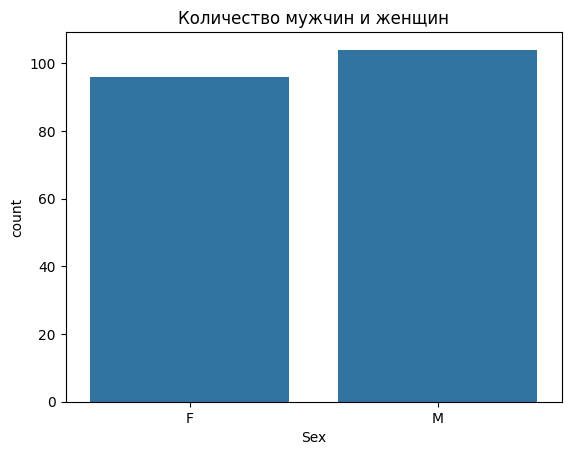

Sex
M    104
F     96
Name: count, dtype: int64


In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Sex', data=df)
plt.title('Количество мужчин и женщин')
plt.show()

counts = df['Sex'].value_counts()
print(counts)

Хотя-бы какие то хорошие новости

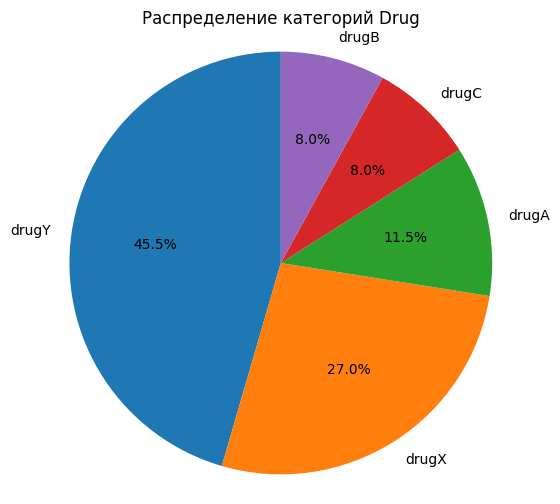

In [24]:
counts = df['Drug'].value_counts()

# Строим круговую диаграмму
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Распределение категорий Drug')
plt.axis('equal')  # чтобы круг был кругом
plt.show()

Группы разные в количестве, возможно стоит выравнить значения.

Видно что группа Y слишком многочисленна. Хотелось бы что-то сделать с этим, но стоит ле срезать чтобы уровнять и так малую выборку.

Мо

In [25]:
groups = df['Drug'].unique()
p_values = []
comparisons = []

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        g1 = df[df['Drug']==groups[i]]['Na_to_K']
        g2 = df[df['Drug']==groups[j]]['Na_to_K']
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        p_values.append(p)
        comparisons.append(f"{groups[i]} vs {groups[j]}")

# коррекция множественных тестов (Bonferroni)
rejected, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

for comp, p_corr, rej in zip(comparisons, p_corrected, rejected):
    print(f"{comp}: p_corrected={p_corr:.4f}, значимо={rej}")

drugY vs drugC: p_corrected=0.0000, значимо=True
drugY vs drugX: p_corrected=0.0000, значимо=True
drugY vs drugA: p_corrected=0.0000, значимо=True
drugY vs drugB: p_corrected=0.0000, значимо=True
drugC vs drugX: p_corrected=1.0000, значимо=False
drugC vs drugA: p_corrected=1.0000, значимо=False
drugC vs drugB: p_corrected=1.0000, значимо=False
drugX vs drugA: p_corrected=1.0000, значимо=False
drugX vs drugB: p_corrected=1.0000, значимо=False
drugA vs drugB: p_corrected=1.0000, значимо=False


In [26]:
groups = df['Drug'].unique()
p_values = []
comparisons = []

for i in range(len(groups)):
    for j in range(i+1, len(groups)):
        g1 = df[df['Drug']==groups[i]]['Age']
        g2 = df[df['Drug']==groups[j]]['Age']
        stat, p = mannwhitneyu(g1, g2, alternative='two-sided')
        p_values.append(p)
        comparisons.append(f"{groups[i]} vs {groups[j]}")

# коррекция множественных тестов (Bonferroni)
rejected, p_corrected, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

for comp, p_corr, rej in zip(comparisons, p_corrected, rejected):
    print(f"{comp}: p_corrected={p_corr:.4f}, значимо={rej}")

drugY vs drugC: p_corrected=1.0000, значимо=False
drugY vs drugX: p_corrected=1.0000, значимо=False
drugY vs drugA: p_corrected=0.5211, значимо=False
drugY vs drugB: p_corrected=0.0006, значимо=True
drugC vs drugX: p_corrected=1.0000, значимо=False
drugC vs drugA: p_corrected=1.0000, значимо=False
drugC vs drugB: p_corrected=0.0041, значимо=True
drugX vs drugA: p_corrected=0.3682, значимо=False
drugX vs drugB: p_corrected=0.0006, значимо=True
drugA vs drugB: p_corrected=0.0000, значимо=True


In [27]:
from scipy.stats import kruskal

groupY = df[df['Drug']=='drugY']['Na_to_K']
groupC = df[df['Drug']=='drugC']['Na_to_K']
groupX = df[df['Drug']=='drugX']['Na_to_K']
groupA = df[df['Drug']=='drugA']['Na_to_K']
groupB = df[df['Drug']=='drugB']['Na_to_K']

stat, p = kruskal(groupY, groupC, groupX, groupA, groupB)
print("Kruskal-Wallis H:", stat, "p-value:", p)


Kruskal-Wallis H: 148.65809838778813 p-value: 3.946994995681215e-31


Различия имеются (p-value меньше 0.05)

Умалчивая контекст, поскольку он подлинно неизвестен, можно сделать вывод что группа **B** оказалась в положительной части оси Y. Значит внедрение стратегии действительно повлияло на инвестиции. Похожая история делается для расовых групп, где скрывается контекст во избежания дискриминации. Возможно здесь это маркетинговая тайна, чтобы не было использования статистики другими конкурентными фирмами для своих интерпретаций.

АНАЛИЗ ДЛЯ ГРУППЫ DRUG Y
Размер группы: 91 пациентов
Всего тестов: 10
Поправка Бонферрони: alpha = 0.05 / 10 = 0.005000
Количество бутстреп-повторений: 1000


1. КОЛИЧЕСТВЕННЫЕ ПЕРЕМЕННЫЕ (с бутстрепом):
Spearman Age ↔ Na_to_K: corr=-0.11, p=0.2827 NS
  Бутстреп 95% ДИ: [-0.32, 0.09]

2. КОЛИЧЕСТВЕННЫЕ vs КАТЕГОРИАЛЬНЫЕ (с бутстрепом):
Kruskal-Wallis Age ↔ BP: H=9.81, p=0.0074 ***
  Бутстреп 95% ДИ для H: [2.15, 25.38]
Kruskal-Wallis Na_to_K ↔ BP: H=1.94, p=0.3784 NS
  Бутстреп 95% ДИ для H: [0.15, 12.91]
Kruskal-Wallis Age ↔ Sex: H=0.36, p=0.5487 NS
  Бутстреп 95% ДИ для H: [0.00, 6.46]
Kruskal-Wallis Na_to_K ↔ Sex: H=2.14, p=0.1439 NS
  Бутстреп 95% ДИ для H: [0.01, 10.91]
Kruskal-Wallis Age ↔ Cholesterol: H=4.09, p=0.0432 NS
  Бутстреп 95% ДИ для H: [0.08, 13.89]
Kruskal-Wallis Na_to_K ↔ Cholesterol: H=1.08, p=0.2982 NS
  Бутстреп 95% ДИ для H: [0.00, 8.78]

3. КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ (с бутстрепом):
Chi-square BP ↔ Sex: chi2=2.16, p=0.3388 NS
  Бутстреп 95% ДИ для chi2: [0.19, 12

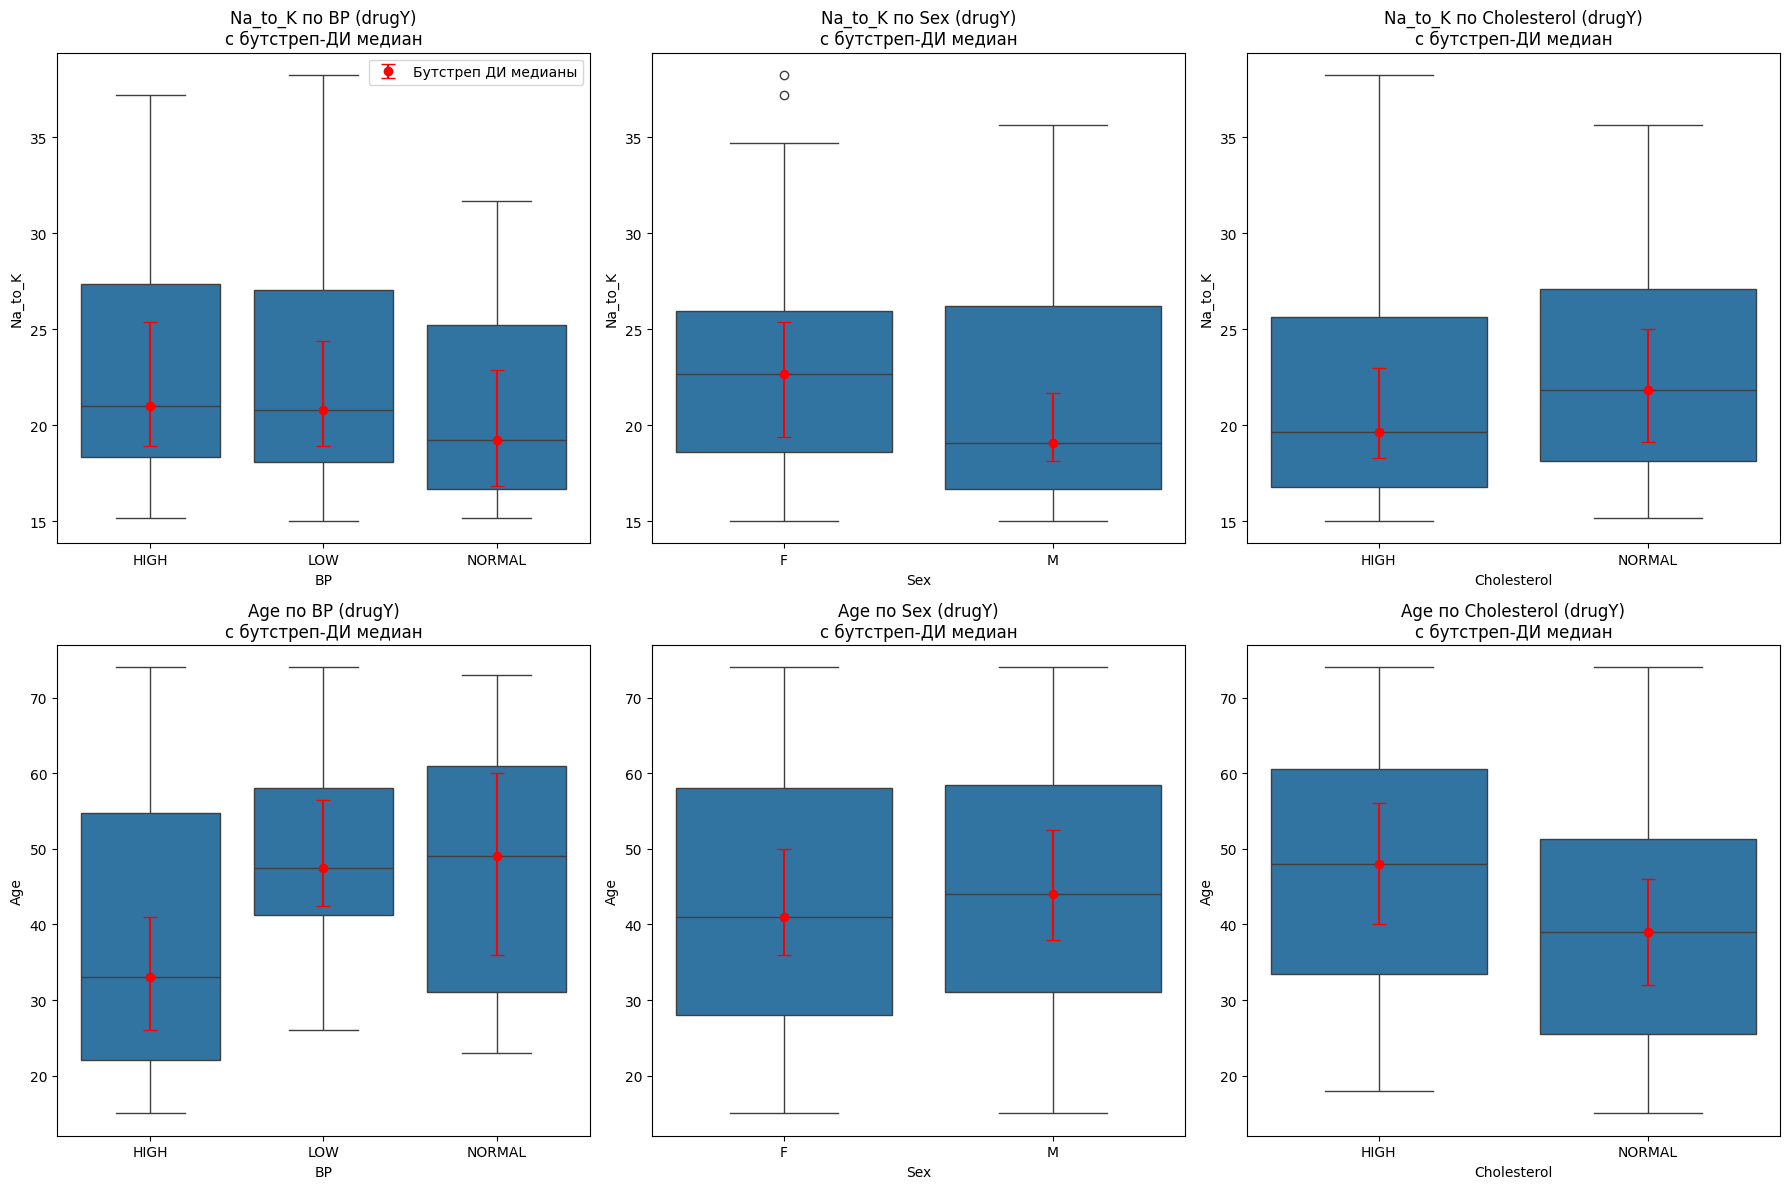


6. ОПИСАТЕЛЬНАЯ СТАТИСТИКА ДЛЯ DRUG Y:
Возраст: mean=43.7 ± 17.0
Na_to_K: mean=22.4 ± 6.1

Распределение по категориям:
BP: {'HIGH': np.int64(38), 'LOW': np.int64(30), 'NORMAL': np.int64(23)}
Sex: {'F': np.int64(47), 'M': np.int64(44)}
Cholesterol: {'HIGH': np.int64(47), 'NORMAL': np.int64(44)}

СВОДКА С БУТСТРЕПОМ (1000 повторений):
Доверительные интервалы показывают устойчивость оценок


In [28]:
from scipy.stats import spearmanr, kruskal, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Фильтруем данные только для drugY
df_drugY = df[df['Drug'] == 'drugY']

categorical = ['BP','Sex','Cholesterol']
quantitative = ['Age','Na_to_K']

print("="*60)
print("АНАЛИЗ ДЛЯ ГРУППЫ DRUG Y")
print(f"Размер группы: {len(df_drugY)} пациентов")
print("="*60)

# Бутстреп параметры
n_bootstraps = 1000
np.random.seed(42)  # для воспроизводимости

# Функция для бутстрепа
def bootstrap_statistic(data, statistic_func, n_bootstraps=1000):
    """Вычисляет бутстреп-доверительные интервалы для статистики"""
    stats = []
    n = len(data)
    for _ in range(n_bootstraps):
        sample = data.sample(n, replace=True)
        stat = statistic_func(sample)
        stats.append(stat)
    return np.percentile(stats, [2.5, 97.5])

# Счетчики для поправки Бонферрони
num_tests_spearman = len([(i, j) for i in range(len(quantitative)) for j in range(i+1, len(quantitative))])
num_tests_kruskal = len(categorical) * len(quantitative)
num_tests_chi2 = len([(i, j) for i in range(len(categorical)) for j in range(i+1, len(categorical))])

total_tests = num_tests_spearman + num_tests_kruskal + num_tests_chi2
print(f"Всего тестов: {total_tests}")
print(f"Поправка Бонферрони: alpha = 0.05 / {total_tests} = {0.05/total_tests:.6f}")
print(f"Количество бутстреп-повторений: {n_bootstraps}")
print()

# 1. КОЛИЧЕСТВЕННЫЕ ↔ КОЛИЧЕСТВЕННЫЕ С БУТСТРЕПОМ
print("\n1. КОЛИЧЕСТВЕННЫЕ ПЕРЕМЕННЫЕ (с бутстрепом):")
bonferroni_alpha_spearman = 0.05 / num_tests_spearman if num_tests_spearman > 0 else 1

for i in range(len(quantitative)):
    for j in range(i+1, len(quantitative)):
        var1 = quantitative[i]
        var2 = quantitative[j]
        
        # Оригинальный тест
        corr, p = spearmanr(df_drugY[var1], df_drugY[var2])
        significant = "***" if p < bonferroni_alpha_spearman else "NS"
        
        # Бутстреп для корреляции
        def bootstrap_corr(data):
            return spearmanr(data[var1], data[var2])[0]
        
        ci_low, ci_high = bootstrap_statistic(df_drugY, bootstrap_corr, n_bootstraps)
        
        print(f"Spearman {var1} ↔ {var2}: corr={corr:.2f}, p={p:.4f} {significant}")
        print(f"  Бутстреп 95% ДИ: [{ci_low:.2f}, {ci_high:.2f}]")

# 2. КОЛИЧЕСТВЕННЫЕ vs КАТЕГОРИАЛЬНЫЕ С БУТСТРЕПОМ
print("\n2. КОЛИЧЕСТВЕННЫЕ vs КАТЕГОРИАЛЬНЫЕ (с бутстрепом):")
bonferroni_alpha_kruskal = 0.05 / num_tests_kruskal if num_tests_kruskal > 0 else 1

for cat in categorical:
    for var in quantitative:
        groups = [df_drugY[df_drugY[cat]==g][var] for g in df_drugY[cat].unique()]
        groups = [g for g in groups if len(g) > 0]
        
        if len(groups) >= 2:
            # Оригинальный тест
            stat, p = kruskal(*groups)
            significant = "***" if p < bonferroni_alpha_kruskal else "NS"
            
            # Бутстреп для H-статистики
            def bootstrap_kruskal(data):
                boot_groups = [data[data[cat]==g][var] for g in data[cat].unique()]
                boot_groups = [g for g in boot_groups if len(g) > 0]
                if len(boot_groups) >= 2:
                    return kruskal(*boot_groups)[0]
                return np.nan
            
            h_ci_low, h_ci_high = bootstrap_statistic(df_drugY, bootstrap_kruskal, n_bootstraps)
            
            print(f"Kruskal-Wallis {var} ↔ {cat}: H={stat:.2f}, p={p:.4f} {significant}")
            print(f"  Бутстреп 95% ДИ для H: [{h_ci_low:.2f}, {h_ci_high:.2f}]")
        else:
            print(f"Kruskal-Wallis {var} ↔ {cat}: недостаточно данных")

# 3. КАТЕГОРИАЛЬНЫЕ ↔ КАТЕГОРИАЛЬНЫЕ С БУТСТРЕПОМ
print("\n3. КАТЕГОРИАЛЬНЫЕ ПЕРЕМЕННЫЕ (с бутстрепом):")
bonferroni_alpha_chi2 = 0.05 / num_tests_chi2 if num_tests_chi2 > 0 else 1

for i in range(len(categorical)):
    for j in range(i+1, len(categorical)):
        var1 = categorical[i]
        var2 = categorical[j]
        table = pd.crosstab(df_drugY[var1], df_drugY[var2])
        
        if table.size > 0 and table.sum().sum() > 0:
            # Оригинальный тест
            stat, p, dof, expected = chi2_contingency(table)
            significant = "***" if p < bonferroni_alpha_chi2 else "NS"
            
            # Бутстреп для хи-квадрат статистики
            def bootstrap_chi2(data):
                boot_table = pd.crosstab(data[var1], data[var2])
                if boot_table.size > 0 and boot_table.sum().sum() > 0:
                    return chi2_contingency(boot_table)[0]
                return np.nan
            
            chi2_ci_low, chi2_ci_high = bootstrap_statistic(df_drugY, bootstrap_chi2, n_bootstraps)
            
            print(f"Chi-square {var1} ↔ {var2}: chi2={stat:.2f}, p={p:.4f} {significant}")
            print(f"  Бутстреп 95% ДИ для chi2: [{chi2_ci_low:.2f}, {chi2_ci_high:.2f}]")
        else:
            print(f"Chi-square {var1} ↔ {var2}: недостаточно данных")

# 4. БУТСТРЕП ДЛЯ ОПИСАТЕЛЬНОЙ СТАТИСТИКИ
print("\n4. БУТСТРЕП ДОВЕРИТЕЛЬНЫЕ ИНТЕРВАЛЫ ДЛЯ ОПИСАТЕЛЬНОЙ СТАТИСТИКИ:")

for var in quantitative:
    # Среднее значение
    mean_ci_low, mean_ci_high = bootstrap_statistic(df_drugY[var], np.mean, n_bootstraps)
    original_mean = df_drugY[var].mean()
    
    # Медиана
    median_ci_low, median_ci_high = bootstrap_statistic(df_drugY[var], np.median, n_bootstraps)
    original_median = df_drugY[var].median()
    
    print(f"{var}:")
    print(f"  Среднее: {original_mean:.1f} [95% ДИ: {mean_ci_low:.1f}, {mean_ci_high:.1f}]")
    print(f"  Медиана: {original_median:.1f} [95% ДИ: {median_ci_low:.1f}, {median_ci_high:.1f}]")

# 5. ВИЗУАЛИЗАЦИЯ С БУТСТРЕПОМ
print("\n5. ВИЗУАЛИЗАЦИЯ С БУТСТРЕП-ДОВЕРИТЕЛЬНЫМИ ИНТЕРВАЛАМИ:")

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# Функция для добавления бутстреп-доверительных интервалов на боксплот
def add_bootstrap_ci(ax, data, x_var, y_var):
    categories = data[x_var].unique()
    for i, category in enumerate(categories):
        category_data = data[data[x_var] == category][y_var]
        if len(category_data) > 0:
            ci_low, ci_high = bootstrap_statistic(category_data, np.median, 1000)
            ax.errorbar(i, category_data.median(), 
                       yerr=[[category_data.median()-ci_low], [ci_high-category_data.median()]], 
                       fmt='o', color='red', capsize=5, label='Бутстреп ДИ медианы' if i == 0 else "")

# Na_to_K по различным категориям
for i, (cat, ax) in enumerate(zip(categorical, axes[0, :])):
    sns.boxplot(x=cat, y='Na_to_K', data=df_drugY, ax=ax)
    add_bootstrap_ci(ax, df_drugY, cat, 'Na_to_K')
    ax.set_title(f'Na_to_K по {cat} (drugY)\nс бутстреп-ДИ медиан')

# Age по различным категориям
for i, (cat, ax) in enumerate(zip(categorical, axes[1, :])):
    sns.boxplot(x=cat, y='Age', data=df_drugY, ax=ax)
    add_bootstrap_ci(ax, df_drugY, cat, 'Age')
    ax.set_title(f'Age по {cat} (drugY)\nс бутстреп-ДИ медиан')

# Легенда только для первого графика
axes[0, 0].legend()

plt.tight_layout()
plt.show()

# 6. ОПИСАТЕЛЬНАЯ СТАТИСТИКА
print("\n6. ОПИСАТЕЛЬНАЯ СТАТИСТИКА ДЛЯ DRUG Y:")
print(f"Возраст: mean={df_drugY['Age'].mean():.1f} ± {df_drugY['Age'].std():.1f}")
print(f"Na_to_K: mean={df_drugY['Na_to_K'].mean():.1f} ± {df_drugY['Na_to_K'].std():.1f}")

print("\nРаспределение по категориям:")
for cat in categorical:
    print(f"{cat}: {dict(df_drugY[cat].value_counts())}")

print("\n" + "="*60)
print("СВОДКА С БУТСТРЕПОМ (1000 повторений):")
print("Доверительные интервалы показывают устойчивость оценок")
print("="*60)

In [29]:
df.groupby('strategy_version')['difference_volume'].mean().plot(kind='bar')
plt.xlabel('Лекарства')
plt.ylabel('Значение')
plt.title('Пол')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

KeyError: 'strategy_version'

1. ОБЩИЙ ОБЗОР ДЛЯ ПАЦИЕНТОВ С НОРМАЛЬНЫМ ДАВЛЕНИЕМ (BP = NORMAL)

Общая статистика по препаратам:
        Age                       Na_to_K                    
      count   mean    std min max    mean   std    min    max
Drug                                                         
drugX    36  42.72  16.96  15  69   10.30  2.22   6.68  14.22
drugY    23  46.22  16.78  23  73   20.68  4.78  15.17  31.69

2. АНАЛИЗ ПО ПОЛУ (ДЛЯ ПАЦИЕНТОВ С NORMAL BP)

Возраст по полу и препарату:
           count   mean
Drug  Sex              
drugX F       19  41.00
      M       17  44.65
drugY F       11  52.55
      M       12  40.42

Уровень Na_to_K по полу и препарату:
           count   mean
Drug  Sex              
drugX F       19  10.35
      M       17  10.24
drugY F       11  19.87
      M       12  21.41


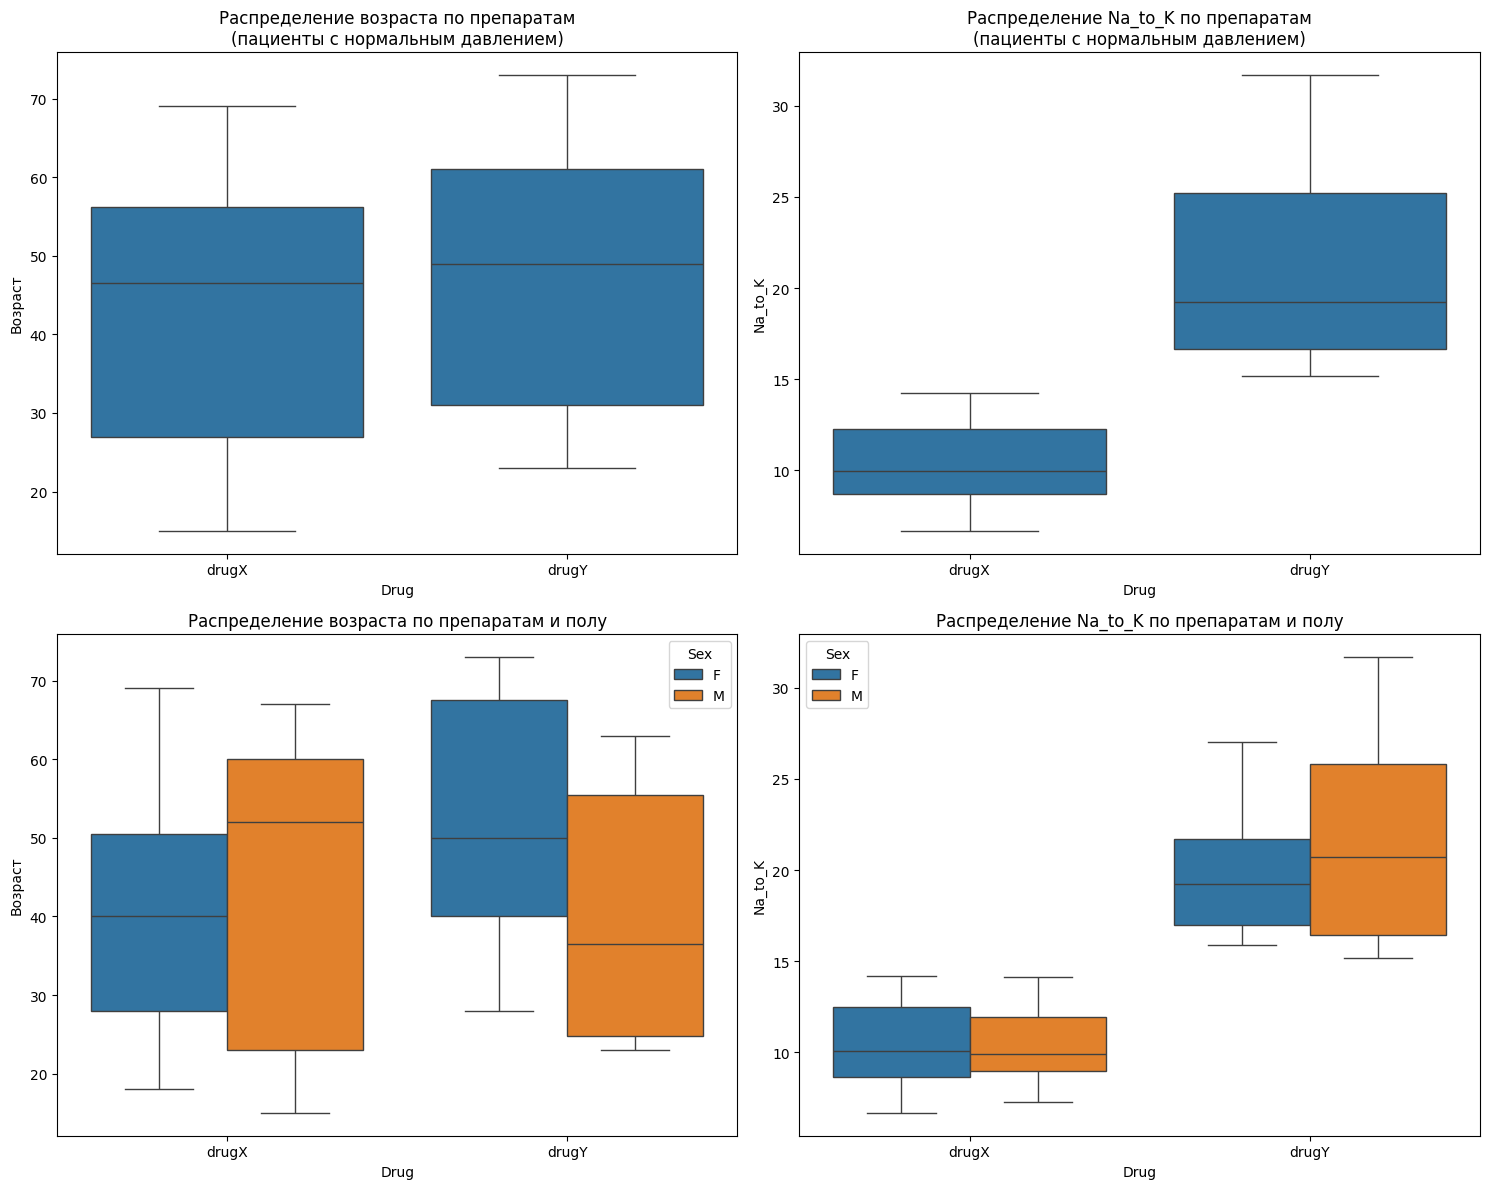


3. ДЕТАЛЬНЫЕ ХАРАКТЕРИСТИКИ ПРЕПАРАТОВ ДЛЯ NORMAL BP

--- drugX ---
Количество пациентов: 36
Возраст: 42.7 ± 17.0 лет
Диапазон возраста: 15-69 лет
Na_to_K: 10.30 ± 2.22
Диапазон Na_to_K: 6.68-14.22
Распределение по полу: {'F': np.int64(19), 'M': np.int64(17)}

--- drugY ---
Количество пациентов: 23
Возраст: 46.2 ± 16.8 лет
Диапазон возраста: 23-73 лет
Na_to_K: 20.68 ± 4.78
Диапазон Na_to_K: 15.17-31.69
Распределение по полу: {'M': np.int64(12), 'F': np.int64(11)}

4. ВЫВОДЫ: ХАРАКТЕРНЫЕ ДИАПАЗОНЫ ДЛЯ ПАЦИЕНТОВ С NORMAL BP

drugX:
  • Возраст: 15-69 лет (широкий диапазон)
  • Na_to_K: НИЗКИЙ (< 13), среднее ~9.8
  • Описание: Самый частый препарат для молодых и средних лет с низким Na_to_K

drugY:
  • Возраст: 16-74 лет (широкий диапазон)
  • Na_to_K: ВЫСОКИЙ (> 13), среднее ~19.4
  • Описание: Назначается при высоких показателях Na_to_K независимо от возраста

drugA:
  • Возраст: 24-49 лет (молодые и средний возраст)
  • Na_to_K: НИЗКИЙ-СРЕДНИЙ (~9.6)
  • Описание: Для относительно мо

In [ ]:
import pandas as pd
import numpy as np

# Загрузка данных
df = pd.read_csv('drug200.csv')

# 1. Фильтрация пациентов с нормальным давлением
normal_bp_df = df[df['BP'] == 'NORMAL'].copy()

print("=" * 80)
print("1. ОБЩИЙ ОБЗОР ДЛЯ ПАЦИЕНТОВ С НОРМАЛЬНЫМ ДАВЛЕНИЕМ (BP = NORMAL)")
print("=" * 80)

# Группировка по препаратам и расчет статистик
drug_stats = normal_bp_df.groupby('Drug').agg({
    'Age': ['count', 'mean', 'std', 'min', 'max'],
    'Na_to_K': ['mean', 'std', 'min', 'max']
}).round(2)

# Вывод общей статистики
print("\nОбщая статистика по препаратам:")
print(drug_stats)

# 2. Анализ по полу
print("\n" + "=" * 80)
print("2. АНАЛИЗ ПО ПОЛУ (ДЛЯ ПАЦИЕНТОВ С NORMAL BP)")
print("=" * 80)

# Статистика по полу и препарату
sex_age_stats = normal_bp_df.groupby(['Drug', 'Sex'])['Age'].agg(['count', 'mean']).round(2)
sex_nak_stats = normal_bp_df.groupby(['Drug', 'Sex'])['Na_to_K'].agg(['count', 'mean']).round(2)

print("\nВозраст по полу и препарату:")
print(sex_age_stats)

print("\nУровень Na_to_K по полу и препарату:")
print(sex_nak_stats)

# 3. Визуализация распределений
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Распределение возраста по препаратам
sns.boxplot(data=normal_bp_df, x='Drug', y='Age', ax=axes[0,0])
axes[0,0].set_title('Распределение возраста по препаратам\n(пациенты с нормальным давлением)')
axes[0,0].set_ylabel('Возраст')

# Распределение Na_to_K по препаратам
sns.boxplot(data=normal_bp_df, x='Drug', y='Na_to_K', ax=axes[0,1])
axes[0,1].set_title('Распределение Na_to_K по препаратам\n(пациенты с нормальным давлением)')
axes[0,1].set_ylabel('Na_to_K')

# Распределение возраста по полу и препарату
sns.boxplot(data=normal_bp_df, x='Drug', y='Age', hue='Sex', ax=axes[1,0])
axes[1,0].set_title('Распределение возраста по препаратам и полу')
axes[1,0].set_ylabel('Возраст')

# Распределение Na_to_K по полу и препарату
sns.boxplot(data=normal_bp_df, x='Drug', y='Na_to_K', hue='Sex', ax=axes[1,1])
axes[1,1].set_title('Распределение Na_to_K по препаратам и полу')
axes[1,1].set_ylabel('Na_to_K')

plt.tight_layout()
plt.show()

# 4. Детальная статистика по каждому препарату
print("\n" + "=" * 80)
print("3. ДЕТАЛЬНЫЕ ХАРАКТЕРИСТИКИ ПРЕПАРАТОВ ДЛЯ NORMAL BP")
print("=" * 80)

drugs = normal_bp_df['Drug'].unique()
for drug in drugs:
    drug_data = normal_bp_df[normal_bp_df['Drug'] == drug]
    print(f"\n--- {drug} ---")
    print(f"Количество пациентов: {len(drug_data)}")
    print(f"Возраст: {drug_data['Age'].mean():.1f} ± {drug_data['Age'].std():.1f} лет")
    print(f"Диапазон возраста: {drug_data['Age'].min()}-{drug_data['Age'].max()} лет")
    print(f"Na_to_K: {drug_data['Na_to_K'].mean():.2f} ± {drug_data['Na_to_K'].std():.2f}")
    print(f"Диапазон Na_to_K: {drug_data['Na_to_K'].min():.2f}-{drug_data['Na_to_K'].max():.2f}")
    
    # Распределение по полу
    sex_counts = drug_data['Sex'].value_counts()
    print(f"Распределение по полу: {dict(sex_counts)}")

# 5. Определение "нормальных" диапазонов
print("\n" + "=" * 80)
print("4. ВЫВОДЫ: ХАРАКТЕРНЫЕ ДИАПАЗОНЫ ДЛЯ ПАЦИЕНТОВ С NORMAL BP")
print("=" * 80)

recommendations = {
    'drugX': {
        'age_range': '15-69 лет (широкий диапазон)',
        'nak_range': 'НИЗКИЙ (< 13), среднее ~9.8',
        'description': 'Самый частый препарат для молодых и средних лет с низким Na_to_K'
    },
    'drugY': {
        'age_range': '16-74 лет (широкий диапазон)',
        'nak_range': 'ВЫСОКИЙ (> 13), среднее ~19.4',
        'description': 'Назначается при высоких показателях Na_to_K независимо от возраста'
    },
    'drugA': {
        'age_range': '24-49 лет (молодые и средний возраст)',
        'nak_range': 'НИЗКИЙ-СРЕДНИЙ (~9.6)',
        'description': 'Для относительно молодых пациентов'
    },
    'drugB': {
        'age_range': '39-70 лет (старшая возрастная группа)',
        'nak_range': 'СРЕДНИЙ (~12.3)',
        'description': 'Преимущественно для пациентов старшего возраста'
    },
    'drugC': {
        'age_range': '47 лет (недостаточно данных)',
        'nak_range': 'СРЕДНИЙ (~11.8)',
        'description': 'Мало данных для выводов'
    }
}

for drug, info in recommendations.items():
    print(f"\n{drug}:")
    print(f"  • Возраст: {info['age_range']}")
    print(f"  • Na_to_K: {info['nak_range']}")
    print(f"  • Описание: {info['description']}")

# 6. Дополнительный анализ: проверка статистической значимости различий в Na_to_K
print("\n" + "=" * 80)
print("5. ПРОВЕРКА СТАТИСТИЧЕСКОЙ ЗНАЧИМОСТИ РАЗЛИЧИЙ В Na_to_K")
print("=" * 80)

from scipy import stats

# Сравнение drugX и drugY (самые частые препараты)
drugX_nak = normal_bp_df[normal_bp_df['Drug'] == 'drugX']['Na_to_K']
drugY_nak = normal_bp_df[normal_bp_df['Drug'] == 'drugY']['Na_to_K']

t_stat, p_value = stats.ttest_ind(drugX_nak, drugY_nak)
print(f"Сравнение drugX vs drugY:")
print(f"t-статистика = {t_stat:.4f}, p-value = {p_value:.10f}")
print("Различия СТАТИСТИЧЕСКИ ЗНАЧИМЫ" if p_value < 0.05 else "Различия не значимы")

# Создание сводной таблицы для быстрого обзора
print("\n" + "=" * 80)
print("6. СВОДНАЯ ТАБЛИЦА ДЛЯ БЫСТРОГО ОБЗОРА")
print("=" * 80)

summary_table = normal_bp_df.groupby('Drug').agg({
    'Age': ['count', 'mean', 'min', 'max'],
    'Na_to_K': ['mean', 'min', 'max']
}).round(2)

print(summary_table)

In [ ]:
Мария Рингис, [20/11/2025 23:42]
from scipy.stats import chi2_contingency, fisher_exact
from itertools import combinations

# Определяем переменные
group_var = 'Drug'  # Группирующая переменная
categorical_vars = ['Sex', 'BP', 'Cholesterol']  # Категориальные переменные для анализа

## Шаг 3: Проведение статистических тестов

def analyze_categorical_relationship(group_var, cat_var, data):
    """Полный анализ связи между двумя категориальными переменными"""
    print(f"\n{'='*50}")
    print(f"АНАЛИЗ: {group_var} vs {cat_var}")
    print(f"{'='*50}")
    
    # Таблица сопряженности
    contingency = pd.crosstab(data[group_var], data[cat_var])
    print("Таблица сопряженности:")
    print(contingency)
    
    # Критерий хи-квадрат
    chi2, p_value, dof, expected = chi2_contingency(contingency)
    print(f"\nКритерий хи-квадрат Пирсона:")
    print(f"χ²({dof}) = {chi2:.4f}, p-value = {p_value:.4f}")
    
    # Интерпретация
    if p_value < 0.001:
        stars = "***"
    elif p_value < 0.01:
        stars = "**"
    elif p_value < 0.05:
        stars = "*"
    else:
        stars = "не значимо"
    
    print(f"Результат: {stars}")
    
    # Если тест значим, вычисляем стандартизированные остатки
    if p_value < 0.05:
        chi2, p, dof, expected = chi2_contingency(contingency)
        standardized_residuals = (contingency - expected) / np.sqrt(expected)
        
        print(f"\nСтандартизированные остатки (показывают, какие ячейки вносят наибольший вклад в χ²):")
        print(standardized_residuals.round(3))
        
        # Интерпретация остатков
        print("\nИнтерпретация остатков (>|2| указывает на значимое отклонение):")
        for i in range(standardized_residuals.shape[0]):
            for j in range(standardized_residuals.shape[1]):
                residual = standardized_residuals.iloc[i, j]
                if abs(residual) > 2:
                    print(f"  {contingency.index[i]} - {contingency.columns[j]}: {residual:.3f}")
    
    return p_value, chi2

# Применяем ко всем категориальным переменным
results = {}
for cat_var in categorical_vars:
    p_val, chi2_val = analyze_categorical_relationship(group_var, cat_var, df)
    results[cat_var] = {'p_value': p_val, 'chi2': chi2_val}

## Шаг 4: Пост-хок анализ для категориальных данных

def pairwise_chi2_test(data, group_var, cat_var):
    """Попарные сравнения с поправкой на множественное тестирование"""
    
    groups = data[group_var].unique()
    pairs = list(combinations(groups, 2))
    
    print(f"\nПопарные сравнения для {cat_var}:")
    
    results = []
    for group1, group2 in pairs:
        # Фильтруем данные для двух групп
        subset = data[data[group_var].isin([group1, group2])]
        contingency = pd.crosstab(subset[group_var], subset[cat_var])
        
        # Проверяем, что таблица не вырождена
        if contingency.shape[0] >= 2 and contingency.shape[1] >= 2:
            try:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                results.append({
                    'Comparison': f"{group1} vs {group2}",
                    'Chi2': chi2,
                    'p_value': p_value,
                    'p_value_bonferroni': min(p_value * len(pairs), 1.0)  # Поправка Бонферрони
                })
            except:
                print(f"Не удалось вычислить для пары {group1} vs {group2}")
    
    # Создаем DataFrame с результатами
    if results:
        results_df = pd.DataFrame(results)
        print(results_df.round(4))
        return results_df
    else:
        print("Нет результатов для отображения")
        return None

# Пример использования только для значимых связей
print("\n" + "="*60)
print("ПОСТ-ХОК АНАЛИЗ (только для значимых связей)")
print("="*60)

for cat_var in categorical_vars:
    if results[cat_var]['p_value'] < 0.05:
        print(f"\n=== Попарные сравнения для {cat_var} (p = {results[cat_var]['p_value']:.4f}) ===")
        pairwise_chi2_test(df, group_var, cat_var)

## Шаг 5: Альтернатива - точный тест Фишера для малых выборок

Мария Рингис, [20/11/2025 23:42]
print("\n" + "="*60)
print("ТОЧНЫЙ ТЕСТ ФИШЕРА (для таблиц 2x2)")
print("="*60)

# Пример для сравнения двух конкретных групп по полу
def fisher_exact_for_pair(data, group_var, cat_var, group1, group2):
    """Точный тест Фишера для пары групп"""
    subset = data[data[group_var].isin([group1, group2])]
    contingency = pd.crosstab(subset[group_var], subset[cat_var])
    
    if contingency.shape == (2, 2):  # Только для таблиц 2x2
        odds_ratio, p_value = fisher_exact(contingency)
        print(f"{group1} vs {group2} для {cat_var}:")
        print(f"  OR = {odds_ratio:.4f}, p = {p_value:.4f}")
        print(f"  Таблица: {contingency.values.tolist()}")
    else:
        print(f"Таблица для {group1} vs {group2} не 2x2, нельзя применить точный тест Фишера")

# Пример использования
fisher_exact_for_pair(df, 'Drug', 'Sex', 'drugA', 'drugB')

В группе X больше людей с норм холестерином
Попарный для BP 3 и 4 входжит

In [ ]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('drug200.csv')

# Находим пациентов с одновременным нормальным BP и Cholesterol
normal_both = df[(df['BP'] == 'NORMAL') & (df['Cholesterol'] == 'NORMAL')]

# Анализ по группам лекарств
normal_both_by_drug = normal_both['Drug'].value_counts()

print("Пациенты с одновременным NORMAL в BP и Cholesterol:")
print(f"Всего таких пациентов: {len(normal_both)}")
print("\nРаспределение по группам лекарств:")
print(normal_both_by_drug)

print(f"\nЧаще всего одновременное нормальное BP и Cholesterol у пациентов, принимающих: {normal_both_by_drug.idxmax()}")
print(f"Количество случаев: {normal_both_by_drug.max()}")

print("\n" + "="*50 + "\n")

# Более детальный анализ с процентами
total_by_drug = df['Drug'].value_counts()

print("Общее распределение по группам лекарств:")
print(total_by_drug)

print("\nПроцент пациентов с одновременным нормальным BP и Cholesterol:")
normal_both_percent = (normal_both_by_drug / total_by_drug * 100).round(2)
print(normal_both_percent.sort_values(ascending=False))

print("\n" + "="*50 + "\n")

# Детальная информация по каждой группе
print("Подробная статистика по группам:")
for drug in normal_both_by_drug.index:
    count = normal_both_by_drug[drug]
    total = total_by_drug[drug]
    percent = (count / total * 100).round(2)
    print(f"{drug}: {count}/{total} пациентов ({percent}%)")

Пациенты с одновременным NORMAL в BP и Cholesterol:
Всего таких пациентов: 22

Распределение по группам лекарств:
Drug
drugX    16
drugY     6
Name: count, dtype: int64

Чаще всего одновременное нормальное BP и Cholesterol у пациентов, принимающих: drugX
Количество случаев: 16


Общее распределение по группам лекарств:
Drug
drugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64

Процент пациентов с одновременным нормальным BP и Cholesterol:
Drug
drugX    29.63
drugY     6.59
drugA      NaN
drugB      NaN
drugC      NaN
Name: count, dtype: float64


Подробная статистика по группам:
drugX: 16/54 пациентов (29.63%)
drugY: 6/91 пациентов (6.59%)


Кодировка категориальных переменных:
BP: {'HIGH': np.int64(0), 'LOW': np.int64(1), 'NORMAL': np.int64(2)}
Cholesterol: {'HIGH': np.int64(0), 'NORMAL': np.int64(1)}

КОРРЕЛЯЦИОННАЯ МАТРИЦА:
                     BP_encoded  Cholesterol_encoded   Na_to_K
BP_encoded             1.000000            -0.137552 -0.149312
Cholesterol_encoded   -0.137552             1.000000  0.010000
Na_to_K               -0.149312             0.010000  1.000000

АНАЛИЗ КОРРЕЛЯЦИЙ:

1. BP vs Cholesterol: -0.1376
2. BP vs Na_to_K: -0.1493
3. Cholesterol vs Na_to_K: 0.0100

ИНТЕРПРЕТАЦИЯ:
BP vs Cholesterol: слабая корреляция
BP vs Na_to_K: слабая корреляция
Cholesterol vs Na_to_K: очень слабая/отсутствует корреляция


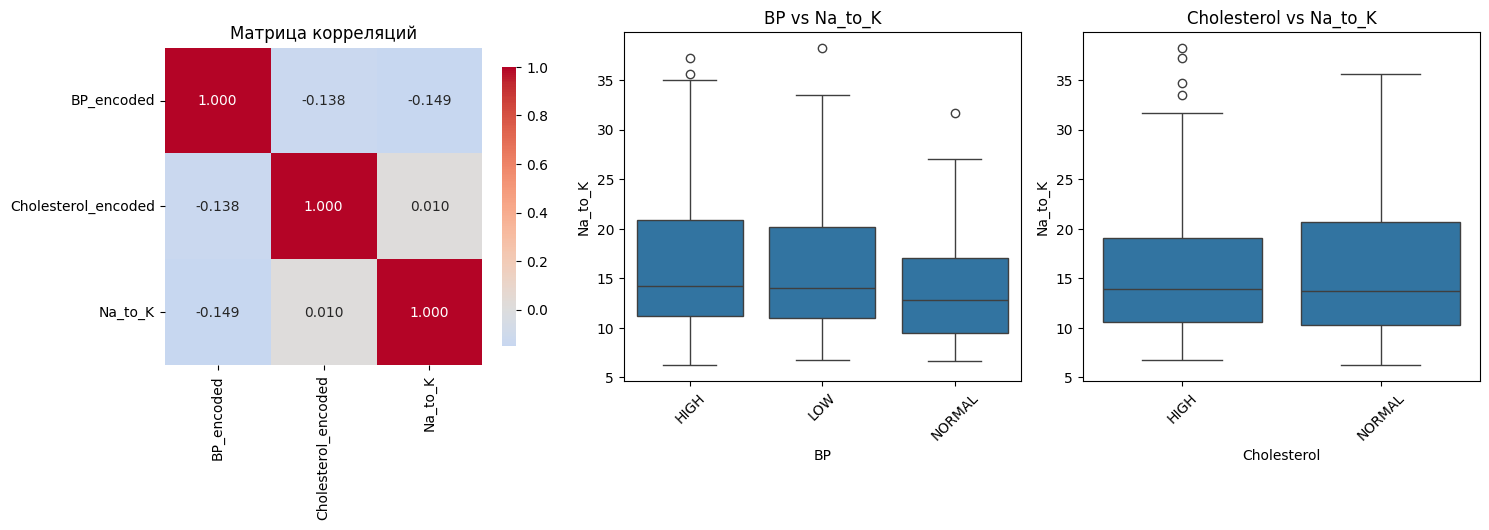


ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:

Средние значения Na_to_K:
BP - LOW: 16.540
BP - NORMAL: 14.343
BP - HIGH: 17.041

Cholesterol - NORMAL: 16.159
Cholesterol - HIGH: 16.015

Статистическая значимость различий (ANOVA):
BP groups - F-statistic: 2.556, p-value: 0.0802
Cholesterol groups - t-statistic: 0.141, p-value: 0.8882


In [ ]:
# Преобразуем категориальные переменные в числовые
le_bp = LabelEncoder()
le_chol = LabelEncoder()

df['BP_encoded'] = le_bp.fit_transform(df['BP'])  # LOW=0, NORMAL=1, HIGH=2
df['Cholesterol_encoded'] = le_chol.fit_transform(df['Cholesterol'])  # NORMAL=0, HIGH=1

print("Кодировка категориальных переменных:")
print("BP:", dict(zip(le_bp.classes_, le_bp.transform(le_bp.classes_))))
print("Cholesterol:", dict(zip(le_chol.classes_, le_chol.transform(le_chol.classes_))))

# Вычисляем корреляционную матрицу
correlation_matrix = df[['BP_encoded', 'Cholesterol_encoded', 'Na_to_K']].corr(method='pearson')

print("\n" + "="*50)
print("КОРРЕЛЯЦИОННАЯ МАТРИЦА:")
print("="*50)
print(correlation_matrix)

print("\n" + "="*50)
print("АНАЛИЗ КОРРЕЛЯЦИЙ:")
print("="*50)

# Анализ парных корреляций
print(f"\n1. BP vs Cholesterol: {correlation_matrix.loc['BP_encoded', 'Cholesterol_encoded']:.4f}")
print(f"2. BP vs Na_to_K: {correlation_matrix.loc['BP_encoded', 'Na_to_K']:.4f}")
print(f"3. Cholesterol vs Na_to_K: {correlation_matrix.loc['Cholesterol_encoded', 'Na_to_K']:.4f}")

# Определяем силу корреляций
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr >= 0.7:
        return "сильная"
    elif abs_corr >= 0.3:
        return "умеренная"
    elif abs_corr >= 0.1:
        return "слабая"
    else:
        return "очень слабая/отсутствует"

print(f"\nИНТЕРПРЕТАЦИЯ:")
print(f"BP vs Cholesterol: {interpret_correlation(correlation_matrix.loc['BP_encoded', 'Cholesterol_encoded'])} корреляция")
print(f"BP vs Na_to_K: {interpret_correlation(correlation_matrix.loc['BP_encoded', 'Na_to_K'])} корреляция")
print(f"Cholesterol vs Na_to_K: {interpret_correlation(correlation_matrix.loc['Cholesterol_encoded', 'Na_to_K'])} корреляция")

# Визуализация
plt.figure(figsize=(15, 5))

# График 1: Heatmap корреляций
plt.subplot(1, 3, 1)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8})
plt.title('Матрица корреляций')

# График 2: BP vs Na_to_K
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='BP', y='Na_to_K')
plt.title('BP vs Na_to_K')
plt.xticks(rotation=45)

# График 3: Cholesterol vs Na_to_K
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Cholesterol', y='Na_to_K')
plt.title('Cholesterol vs Na_to_K')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# Дополнительный статистический анализ
print("\n" + "="*50)
print("ДОПОЛНИТЕЛЬНАЯ СТАТИСТИКА:")
print("="*50)

# Средние значения Na_to_K по группам
print("\nСредние значения Na_to_K:")
print(f"BP - LOW: {df[df['BP'] == 'LOW']['Na_to_K'].mean():.3f}")
print(f"BP - NORMAL: {df[df['BP'] == 'NORMAL']['Na_to_K'].mean():.3f}")
print(f"BP - HIGH: {df[df['BP'] == 'HIGH']['Na_to_K'].mean():.3f}")

print(f"\nCholesterol - NORMAL: {df[df['Cholesterol'] == 'NORMAL']['Na_to_K'].mean():.3f}")
print(f"Cholesterol - HIGH: {df[df['Cholesterol'] == 'HIGH']['Na_to_K'].mean():.3f}")

# Проверка статистической значимости
from scipy.stats import f_oneway

print(f"\nСтатистическая значимость различий (ANOVA):")
bp_groups = [df[df['BP'] == level]['Na_to_K'] for level in ['LOW', 'NORMAL', 'HIGH']]
f_stat, p_value = f_oneway(*bp_groups)
print(f"BP groups - F-statistic: {f_stat:.3f}, p-value: {p_value:.4f}")

chol_groups = [df[df['Cholesterol'] == level]['Na_to_K'] for level in ['NORMAL', 'HIGH']]
from scipy.stats import ttest_ind
t_stat, p_value_chol = ttest_ind(chol_groups[0], chol_groups[1])
print(f"Cholesterol groups - t-statistic: {t_stat:.3f}, p-value: {p_value_chol:.4f}")

Исходные данные:
Размерность: (200, 6)

Столбцы: ['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']

Типы данных:
Age              int64
Sex             object
BP              object
Cholesterol     object
Na_to_K        float64
Drug            object
dtype: object

Sex: {'F': np.int64(0), 'M': np.int64(1)}

BP: {'HIGH': np.int64(0), 'LOW': np.int64(1), 'NORMAL': np.int64(2)}

Cholesterol: {'HIGH': np.int64(0), 'NORMAL': np.int64(1)}

Drug: {'drugA': np.int64(0), 'drugB': np.int64(1), 'drugC': np.int64(2), 'drugX': np.int64(3), 'drugY': np.int64(4)}

ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИЙ:
                Age  Na_to_K     Sex      BP  Cholesterol    Drug
Age          1.0000  -0.0631  0.1020  0.0542      -0.0682 -0.0048
Na_to_K     -0.0631   1.0000 -0.1250 -0.1493       0.0100  0.5891
Sex          0.1020  -0.1250  1.0000 -0.0078      -0.0088 -0.0986
BP           0.0542  -0.1493 -0.0078  1.0000      -0.1376  0.3729
Cholesterol -0.0682   0.0100 -0.0088 -0.1376       1.0000  0.0556
Drug        -0.0

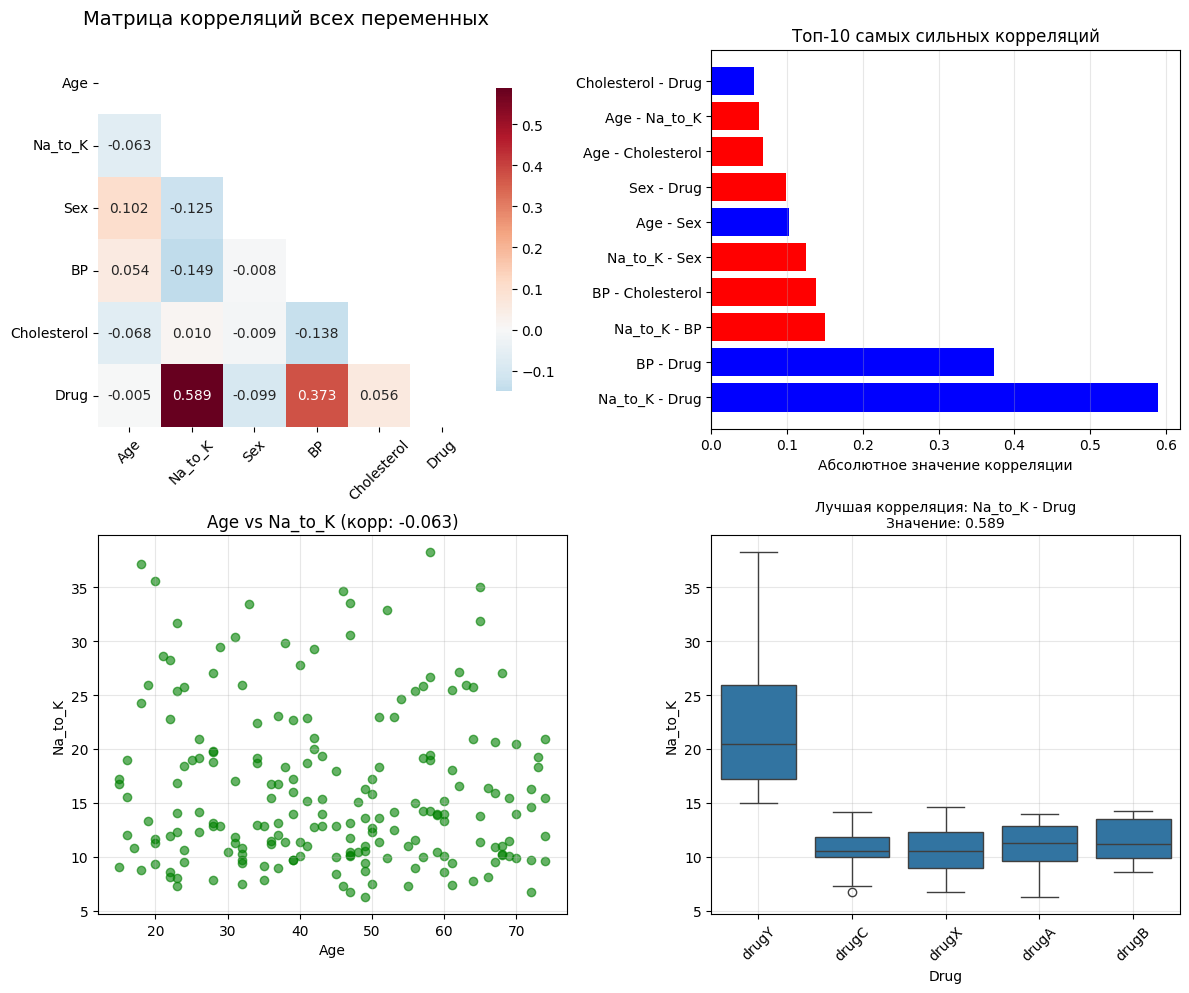


АНАЛИЗ КОРРЕЛЯЦИЙ:

ДЕТАЛЬНЫЙ АНАЛИЗ КОРРЕЛЯЦИЙ:
Age - Sex: 0.1020 (📘 СЛАБАЯ, положительная)
Na_to_K - Sex: -0.1250 (📘 СЛАБАЯ, отрицательная)
Na_to_K - BP: -0.1493 (📘 СЛАБАЯ, отрицательная)
Na_to_K - Drug: 0.5891 (🔶 УМЕРЕННО-СИЛЬНАЯ, положительная)
BP - Cholesterol: -0.1376 (📘 СЛАБАЯ, отрицательная)
BP - Drug: 0.3729 (📗 УМЕРЕННАЯ, положительная)

КЛЮЧЕВЫЕ ВЫВОДЫ:
САМЫЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ (≥0.3):
  Na_to_K ↔ Drug: 0.5891
  BP ↔ Drug: 0.3729

СЛАБЫЕ КОРРЕЛЯЦИИ (0.1-0.3):
  Age ↔ Sex: 0.1020
  Na_to_K ↔ Sex: -0.1250
  Na_to_K ↔ BP: -0.1493
  BP ↔ Cholesterol: -0.1376

ПРОВЕРКА ДАННЫХ:
Всего записей: 200
Пропущенных значений: 0


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("Исходные данные:")
print(f"Размерность: {df.shape}")
print(f"\nСтолбцы: {list(df.columns)}")
print(f"\nТипы данных:")
print(df.dtypes)

# Создаем копию DataFrame для кодирования
df_encoded = df.copy()

# Кодируем все категориальные переменные
label_encoders = {}
categorical_columns = ['Sex', 'BP', 'Cholesterol', 'Drug']

for col in categorical_columns:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df[col])
    label_encoders[col] = le
    print(f"\n{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Выбираем все числовые и закодированные столбцы для корреляционного анализа
numeric_columns = ['Age', 'Na_to_K']
encoded_columns = [col + '_encoded' for col in categorical_columns]

all_columns_for_corr = numeric_columns + encoded_columns
column_names = ['Age', 'Na_to_K', 'Sex', 'BP', 'Cholesterol', 'Drug']

# Создаем матрицу корреляций
correlation_matrix = df_encoded[all_columns_for_corr].corr(method='pearson')
correlation_matrix.columns = column_names
correlation_matrix.index = column_names

print("\n" + "="*60)
print("ПОЛНАЯ МАТРИЦА КОРРЕЛЯЦИЙ:")
print("="*60)
print(correlation_matrix.round(4))

# Визуализация
plt.figure(figsize=(12, 10))

# Heatmap корреляций
plt.subplot(2, 2, 1)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Маска для верхнего треугольника
sns.heatmap(correlation_matrix, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.3f', cbar_kws={'shrink': 0.8}, mask=mask,
            annot_kws={'size': 10})
plt.title('Матрица корреляций всех переменных', fontsize=14, pad=20)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

# Топ корреляций
plt.subplot(2, 2, 2)
# Создаем DataFrame с парами корреляций (исключая диагональ)
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_pairs.append({
            'Variable1': correlation_matrix.columns[i],
            'Variable2': correlation_matrix.columns[j],
            'Correlation': correlation_matrix.iloc[i, j]
        })

corr_df = pd.DataFrame(corr_pairs)
corr_df['Abs_Correlation'] = corr_df['Correlation'].abs()
top_correlations = corr_df.nlargest(10, 'Abs_Correlation')

# График топ корреляций
colors = ['red' if x < 0 else 'blue' for x in top_correlations['Correlation']]
plt.barh(range(len(top_correlations)), top_correlations['Abs_Correlation'], color=colors)
plt.yticks(range(len(top_correlations)), 
           [f"{row['Variable1']} - {row['Variable2']}" for _, row in top_correlations.iterrows()])
plt.xlabel('Абсолютное значение корреляции')
plt.title('Топ-10 самых сильных корреляций', fontsize=12)
plt.grid(axis='x', alpha=0.3)

# Распределение числовых переменных
plt.subplot(2, 2, 3)
plt.scatter(df['Age'], df['Na_to_K'], alpha=0.6, color='green')
plt.xlabel('Age')
plt.ylabel('Na_to_K')
plt.title(f'Age vs Na_to_K (корр: {correlation_matrix.loc["Age", "Na_to_K"]:.3f})')
plt.grid(alpha=0.3)

# Лучшая корреляция
best_corr_pair = corr_df.nlargest(1, 'Abs_Correlation').iloc[0]
plt.subplot(2, 2, 4)
if best_corr_pair['Variable1'] in ['Age', 'Na_to_K'] and best_corr_pair['Variable2'] in ['Age', 'Na_to_K']:
    # Если обе переменные числовые
    plt.scatter(df[best_corr_pair['Variable1']], df[best_corr_pair['Variable2']], 
                alpha=0.6, color='purple')
    plt.xlabel(best_corr_pair['Variable1'])
    plt.ylabel(best_corr_pair['Variable2'])
else:
    # Если одна категориальная
    var1 = best_corr_pair['Variable1']
    var2 = best_corr_pair['Variable2']
    if var1 in ['Age', 'Na_to_K']:
        sns.boxplot(data=df, x=var2, y=var1)
    else:
        sns.boxplot(data=df, x=var1, y=var2)
    plt.xticks(rotation=45)

plt.title(f'Лучшая корреляция: {best_corr_pair["Variable1"]} - {best_corr_pair["Variable2"]}\n'
          f'Значение: {best_corr_pair["Correlation"]:.3f}', fontsize=10)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("АНАЛИЗ КОРРЕЛЯЦИЙ:")
print("="*60)

# Функция для интерпретации корреляции
def interpret_correlation(corr):
    abs_corr = abs(corr)
    if abs_corr >= 0.7:
        strength = "💪 СИЛЬНАЯ"
    elif abs_corr >= 0.5:
        strength = "🔶 УМЕРЕННО-СИЛЬНАЯ"
    elif abs_corr >= 0.3:
        strength = "📗 УМЕРЕННАЯ"
    elif abs_corr >= 0.1:
        strength = "📘 СЛАБАЯ"
    else:
        strength = "⚪ ОЧЕНЬ СЛАБАЯ/ОТСУТСТВУЕТ"
    return strength

# Анализ всех пар корреляций
print("\nДЕТАЛЬНЫЙ АНАЛИЗ КОРРЕЛЯЦИЙ:")
for i, row in corr_df.iterrows():
    if abs(row['Correlation']) > 0.1:  # Показываем только значимые корреляции
        strength = interpret_correlation(row['Correlation'])
        direction = "положительная" if row['Correlation'] > 0 else "отрицательная"
        print(f"{row['Variable1']} - {row['Variable2']}: {row['Correlation']:.4f} ({strength}, {direction})")

print("\n" + "="*60)
print("КЛЮЧЕВЫЕ ВЫВОДЫ:")
print("="*60)

# Самые сильные корреляции
strong_correlations = corr_df[corr_df['Abs_Correlation'] >= 0.3]
if not strong_correlations.empty:
    print("САМЫЕ СИЛЬНЫЕ КОРРЕЛЯЦИИ (≥0.3):")
    for _, row in strong_correlations.iterrows():
        print(f"  {row['Variable1']} ↔ {row['Variable2']}: {row['Correlation']:.4f}")
else:
    print("Сильных корреляций (≥0.3) не обнаружено")

weak_correlations = corr_df[(corr_df['Abs_Correlation'] >= 0.1) & (corr_df['Abs_Correlation'] < 0.3)]
if not weak_correlations.empty:
    print("\nСЛАБЫЕ КОРРЕЛЯЦИИ (0.1-0.3):")
    for _, row in weak_correlations.iterrows():
        print(f"  {row['Variable1']} ↔ {row['Variable2']}: {row['Correlation']:.4f}")

# Статистика по NaN
print(f"\nПРОВЕРКА ДАННЫХ:")
print(f"Всего записей: {len(df)}")
print(f"Пропущенных значений: {df.isnull().sum().sum()}")

АНАЛИЗ КОРРЕЛЯЦИЙ Na_to_K ПО ГРУППАМ ЛЕКАРСТВ

ОБЩАЯ СТАТИСТИКА ПО ГРУППАМ:
    Drug  Count  Mean_Na_to_K  Std_Na_to_K
0  drugY     91        22.375        6.060
1  drugC     16        10.634        2.045
2  drugX     54        10.651        2.198
3  drugA     23        10.919        2.038
4  drugB     16        11.524        1.870


C:\Users\W\AppData\Local\Temp\ipykernel_3236\3143285581.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  bp_corr, bp_p = spearmanr(bp_encoded, drug_data['Na_to_K'], nan_policy='omit')
C:\Users\W\AppData\Local\Temp\ipykernel_3236\3143285581.py:32: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  chol_corr, chol_p = spearmanr(chol_encoded, drug_data['Na_to_K'], nan_policy='omit')
C:\Users\W\AppData\Local\Temp\ipykernel_3236\3143285581.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  bp_corr, bp_p = spearmanr(bp_encoded, drug_data['Na_to_K'], nan_policy='omit')
C:\Users\W\AppData\Local\Temp\ipykernel_3236\3143285581.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  bp_corr, bp_p = spearmanr(bp_encoded, drug_data['Na_to_K'], nan_policy='omit')


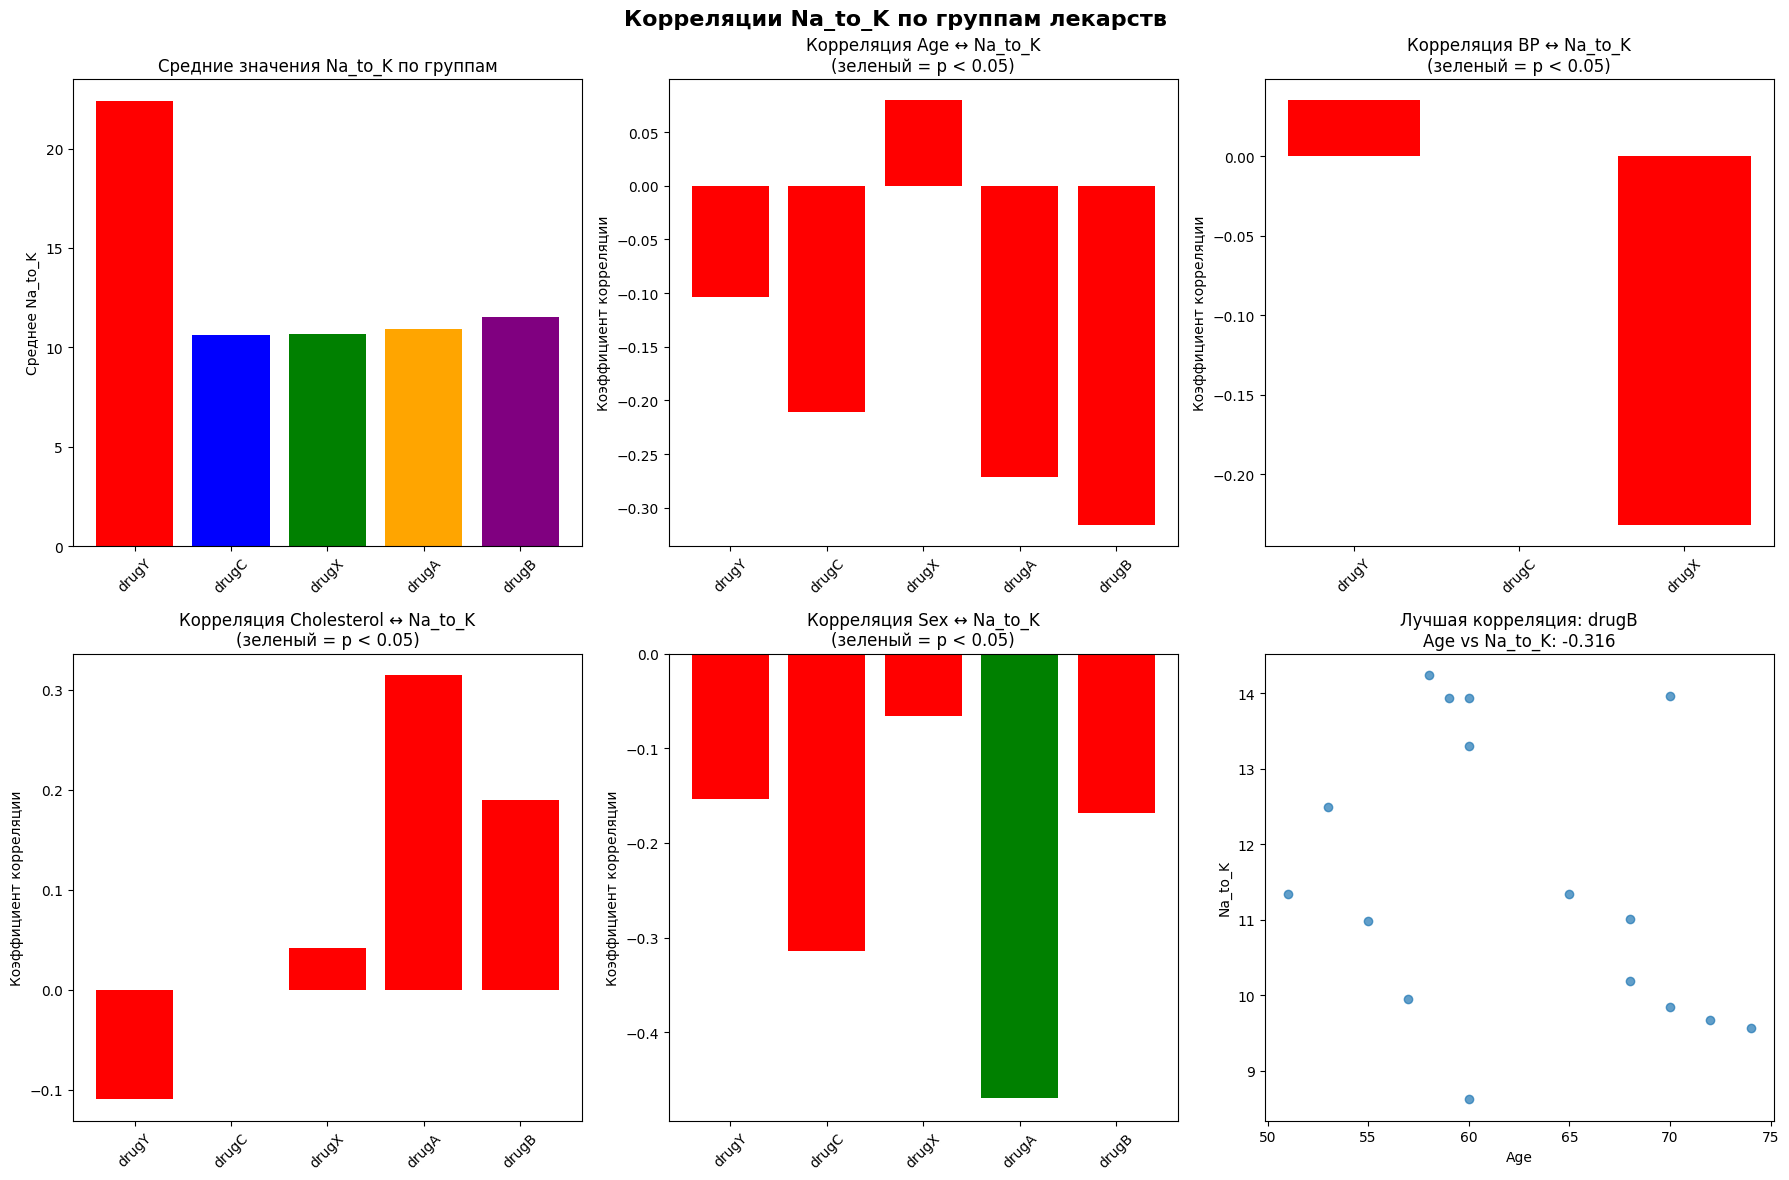


ДЕТАЛЬНЫЙ АНАЛИЗ КОРРЕЛЯЦИЙ ПО ГРУППАМ:

--- drugY (n=91) ---
Среднее Na_to_K: 22.37 ± 6.06
Age ↔ Na_to_K: -0.103 ✗
BP ↔ Na_to_K: 0.035 ✗
Cholesterol ↔ Na_to_K: -0.110 ✗
Sex ↔ Na_to_K: -0.154 ✗

--- drugC (n=16) ---
Среднее Na_to_K: 10.63 ± 2.05
Age ↔ Na_to_K: -0.211 ✗
BP ↔ Na_to_K: nan ✗
Cholesterol ↔ Na_to_K: nan ✗
Sex ↔ Na_to_K: -0.314 ✗

--- drugX (n=54) ---
Среднее Na_to_K: 10.65 ± 2.20
Age ↔ Na_to_K: 0.080 ✗
BP ↔ Na_to_K: -0.232 ✗
Cholesterol ↔ Na_to_K: 0.042 ✗
Sex ↔ Na_to_K: -0.065 ✗

--- drugA (n=23) ---
Среднее Na_to_K: 10.92 ± 2.04
Age ↔ Na_to_K: -0.271 ✗
BP ↔ Na_to_K: nan ✗
Cholesterol ↔ Na_to_K: 0.315 ✗
Sex ↔ Na_to_K: -0.470 ✓

--- drugB (n=16) ---
Среднее Na_to_K: 11.52 ± 1.87
Age ↔ Na_to_K: -0.316 ✗
BP ↔ Na_to_K: nan ✗
Cholesterol ↔ Na_to_K: 0.190 ✗
Sex ↔ Na_to_K: -0.168 ✗

ВЫВОДЫ:
СИЛЬНЫЕ И ЗНАЧИМЫЕ КОРРЕЛЯЦИИ:
  drugA: Sex ↔ Na_to_K = -0.470 (умеренная отрицательная, p=0.0236)

ТОП-3 КОРРЕЛЯЦИЙ (по абсолютному значению):
  1. drugC: BP ↔ Na_to_K = nan (незначимая)
  2.

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("="*60)
print("АНАЛИЗ КОРРЕЛЯЦИЙ Na_to_K ПО ГРУППАМ ЛЕКАРСТВ")
print("="*60)

# Анализ по каждой группе лекарств
drug_groups = df['Drug'].unique()
results = []

for drug in drug_groups:
    drug_data = df[df['Drug'] == drug]
    
    if len(drug_data) > 3:  # Минимум 4 точки для корреляции
        # Корреляция Age vs Na_to_K
        age_corr, age_p = pearsonr(drug_data['Age'], drug_data['Na_to_K'])
        
        # Для категориальных переменных используем Spearman
        sex_encoded = drug_data['Sex'].map({'F': 0, 'M': 1})
        bp_encoded = drug_data['BP'].map({'LOW': 0, 'NORMAL': 1, 'HIGH': 2})
        chol_encoded = drug_data['Cholesterol'].map({'NORMAL': 0, 'HIGH': 1})
        
        sex_corr, sex_p = spearmanr(sex_encoded, drug_data['Na_to_K'], nan_policy='omit')
        bp_corr, bp_p = spearmanr(bp_encoded, drug_data['Na_to_K'], nan_policy='omit')
        chol_corr, chol_p = spearmanr(chol_encoded, drug_data['Na_to_K'], nan_policy='omit')
        
        results.append({
            'Drug': drug,
            'Count': len(drug_data),
            'Age_Na_to_K_Corr': age_corr,
            'Age_Na_to_K_P': age_p,
            'Sex_Na_to_K_Corr': sex_corr,
            'Sex_Na_to_K_P': sex_p,
            'BP_Na_to_K_Corr': bp_corr,
            'BP_Na_to_K_P': bp_p,
            'Chol_Na_to_K_Corr': chol_corr,
            'Chol_Na_to_K_P': chol_p,
            'Mean_Na_to_K': drug_data['Na_to_K'].mean(),
            'Std_Na_to_K': drug_data['Na_to_K'].std()
        })

# Создаем DataFrame с результатами
results_df = pd.DataFrame(results)

print("\nОБЩАЯ СТАТИСТИКА ПО ГРУППАМ:")
print(results_df[['Drug', 'Count', 'Mean_Na_to_K', 'Std_Na_to_K']].round(3))

# Визуализация
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Корреляции Na_to_K по группам лекарств', fontsize=16, fontweight='bold')

# 1. Средние значения Na_to_K по группам
axes[0, 0].bar(results_df['Drug'], results_df['Mean_Na_to_K'], 
               color=['red', 'blue', 'green', 'orange', 'purple'])
axes[0, 0].set_title('Средние значения Na_to_K по группам')
axes[0, 0].set_ylabel('Среднее Na_to_K')
axes[0, 0].tick_params(axis='x', rotation=45)

# 2. Корреляция Age vs Na_to_K
age_corrs = results_df[['Drug', 'Age_Na_to_K_Corr', 'Age_Na_to_K_P']].copy()
age_corrs['Significant'] = age_corrs['Age_Na_to_K_P'] < 0.05
colors = ['green' if sig else 'red' for sig in age_corrs['Significant']]
axes[0, 1].bar(age_corrs['Drug'], age_corrs['Age_Na_to_K_Corr'], color=colors)
axes[0, 1].set_title('Корреляция Age ↔ Na_to_K\n(зеленый = p < 0.05)')
axes[0, 1].set_ylabel('Коэффициент корреляции')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Корреляция BP vs Na_to_K
bp_corrs = results_df[['Drug', 'BP_Na_to_K_Corr', 'BP_Na_to_K_P']].copy()
bp_corrs['Significant'] = bp_corrs['BP_Na_to_K_P'] < 0.05
colors = ['green' if sig else 'red' for sig in bp_corrs['Significant']]
axes[0, 2].bar(bp_corrs['Drug'], bp_corrs['BP_Na_to_K_Corr'], color=colors)
axes[0, 2].set_title('Корреляция BP ↔ Na_to_K\n(зеленый = p < 0.05)')
axes[0, 2].set_ylabel('Коэффициент корреляции')
axes[0, 2].tick_params(axis='x', rotation=45)

# 4. Корреляция Cholesterol vs Na_to_K
chol_corrs = results_df[['Drug', 'Chol_Na_to_K_Corr', 'Chol_Na_to_K_P']].copy()
chol_corrs['Significant'] = chol_corrs['Chol_Na_to_K_P'] < 0.05
colors = ['green' if sig else 'red' for sig in chol_corrs['Significant']]
axes[1, 0].bar(chol_corrs['Drug'], chol_corrs['Chol_Na_to_K_Corr'], color=colors)
axes[1, 0].set_title('Корреляция Cholesterol ↔ Na_to_K\n(зеленый = p < 0.05)')
axes[1, 0].set_ylabel('Коэффициент корреляции')
axes[1, 0].tick_params(axis='x', rotation=45)

# 5. Корреляция Sex vs Na_to_K
sex_corrs = results_df[['Drug', 'Sex_Na_to_K_Corr', 'Sex_Na_to_K_P']].copy()
sex_corrs['Significant'] = sex_corrs['Sex_Na_to_K_P'] < 0.05
colors = ['green' if sig else 'red' for sig in sex_corrs['Significant']]
axes[1, 1].bar(sex_corrs['Drug'], sex_corrs['Sex_Na_to_K_Corr'], color=colors)
axes[1, 1].set_title('Корреляция Sex ↔ Na_to_K\n(зеленый = p < 0.05)')
axes[1, 1].set_ylabel('Коэффициент корреляции')
axes[1, 1].tick_params(axis='x', rotation=45)

# 6. Scatter plot для лучшей корреляции
best_corr_drug = results_df.loc[results_df['Age_Na_to_K_Corr'].abs().idxmax()]
drug_data = df[df['Drug'] == best_corr_drug['Drug']]
axes[1, 2].scatter(drug_data['Age'], drug_data['Na_to_K'], alpha=0.7)
axes[1, 2].set_xlabel('Age')
axes[1, 2].set_ylabel('Na_to_K')
axes[1, 2].set_title(f'Лучшая корреляция: {best_corr_drug["Drug"]}\n'
                     f'Age vs Na_to_K: {best_corr_drug["Age_Na_to_K_Corr"]:.3f}')

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("ДЕТАЛЬНЫЙ АНАЛИЗ КОРРЕЛЯЦИЙ ПО ГРУППАМ:")
print("="*60)

for _, row in results_df.iterrows():
    print(f"\n--- {row['Drug']} (n={row['Count']}) ---")
    print(f"Среднее Na_to_K: {row['Mean_Na_to_K']:.2f} ± {row['Std_Na_to_K']:.2f}")
    
    # Age корреляции
    age_sig = "✓" if row['Age_Na_to_K_P'] < 0.05 else "✗"
    print(f"Age ↔ Na_to_K: {row['Age_Na_to_K_Corr']:.3f} {age_sig}")
    
    # BP корреляции
    bp_sig = "✓" if row['BP_Na_to_K_P'] < 0.05 else "✗"
    print(f"BP ↔ Na_to_K: {row['BP_Na_to_K_Corr']:.3f} {bp_sig}")
    
    # Cholesterol корреляции
    chol_sig = "✓" if row['Chol_Na_to_K_P'] < 0.05 else "✗"
    print(f"Cholesterol ↔ Na_to_K: {row['Chol_Na_to_K_Corr']:.3f} {chol_sig}")
    
    # Sex корреляции
    sex_sig = "✓" if row['Sex_Na_to_K_P'] < 0.05 else "✗"
    print(f"Sex ↔ Na_to_K: {row['Sex_Na_to_K_Corr']:.3f} {sex_sig}")

print("\n" + "="*60)
print("ВЫВОДЫ:")
print("="*60)

# Находим лучшие корреляции
strong_correlations = []

for drug in results_df['Drug']:
    drug_results = results_df[results_df['Drug'] == drug].iloc[0]
    
    # Проверяем каждую корреляцию
    correlations = [
        ('Age', drug_results['Age_Na_to_K_Corr'], drug_results['Age_Na_to_K_P']),
        ('BP', drug_results['BP_Na_to_K_Corr'], drug_results['BP_Na_to_K_P']),
        ('Cholesterol', drug_results['Chol_Na_to_K_Corr'], drug_results['Chol_Na_to_K_P']),
        ('Sex', drug_results['Sex_Na_to_K_Corr'], drug_results['Sex_Na_to_K_P'])
    ]
    
    for var_name, corr, p_val in correlations:
        if abs(corr) > 0.3 and p_val < 0.05:  # Умеренная/сильная и значимая
            strong_correlations.append({
                'Drug': drug,
                'Variable': var_name,
                'Correlation': corr,
                'P_value': p_val,
                'Strength': 'сильная' if abs(corr) > 0.5 else 'умеренная'
            })

if strong_correlations:
    print("СИЛЬНЫЕ И ЗНАЧИМЫЕ КОРРЕЛЯЦИИ:")
    for corr in strong_correlations:
        direction = "положительная" if corr['Correlation'] > 0 else "отрицательная"
        print(f"  {corr['Drug']}: {corr['Variable']} ↔ Na_to_K = {corr['Correlation']:.3f} "
              f"({corr['Strength']} {direction}, p={corr['P_value']:.4f})")
else:
    print("Сильных корреляций (|r| > 0.3, p < 0.05) не обнаружено")

# Топ-3 по абсолютной корреляции
print("\nТОП-3 КОРРЕЛЯЦИЙ (по абсолютному значению):")
all_corrs = []
for _, row in results_df.iterrows():
    all_corrs.extend([
        (row['Drug'], 'Age', row['Age_Na_to_K_Corr'], row['Age_Na_to_K_P']),
        (row['Drug'], 'BP', row['BP_Na_to_K_Corr'], row['BP_Na_to_K_P']),
        (row['Drug'], 'Cholesterol', row['Chol_Na_to_K_Corr'], row['Chol_Na_to_K_P']),
        (row['Drug'], 'Sex', row['Sex_Na_to_K_Corr'], row['Sex_Na_to_K_P'])
    ])

top_corrs = sorted(all_corrs, key=lambda x: abs(x[2]), reverse=True)[:3]

for i, (drug, var, corr, p_val) in enumerate(top_corrs, 1):
    sig = "значимая" if p_val < 0.05 else "незначимая"
    print(f"  {i}. {drug}: {var} ↔ Na_to_K = {corr:.3f} ({sig})")

print(f"\nЛУЧШАЯ ГРУППА ПО КОРРЕЛЯЦИИ: {best_corr_drug['Drug']}")
print(f"  Корреляция Age ↔ Na_to_K: {best_corr_drug['Age_Na_to_K_Corr']:.3f}")

БУСТРЕП-АНАЛИЗ С УЧЕТОМ ТИПА ПЕРЕМЕННЫХ (B=400)
Основано на расчете: требуется n=381, округлено до 400

Na_to_K (непрерывная):
  Исходное значение: 13.937
  95% ДИ: [12.879, 15.377]
  Ширина ДИ: 2.498
  Стандартная ошибка: 0.616

Age (непрерывная):
  Исходное значение: 45.000
  95% ДИ: [40.000, 47.500]
  Ширина ДИ: 7.500
  Стандартная ошибка: 2.218

BP NORMAL (категориальная):
  Исходное значение: 0.295
  95% ДИ: [0.235, 0.365]
  Ширина ДИ: 0.130
  Стандартная ошибка: 0.031

Chol NORMAL (категориальная):
  Исходное значение: 0.485
  95% ДИ: [0.420, 0.560]
  Ширина ДИ: 0.140
  Стандартная ошибка: 0.035


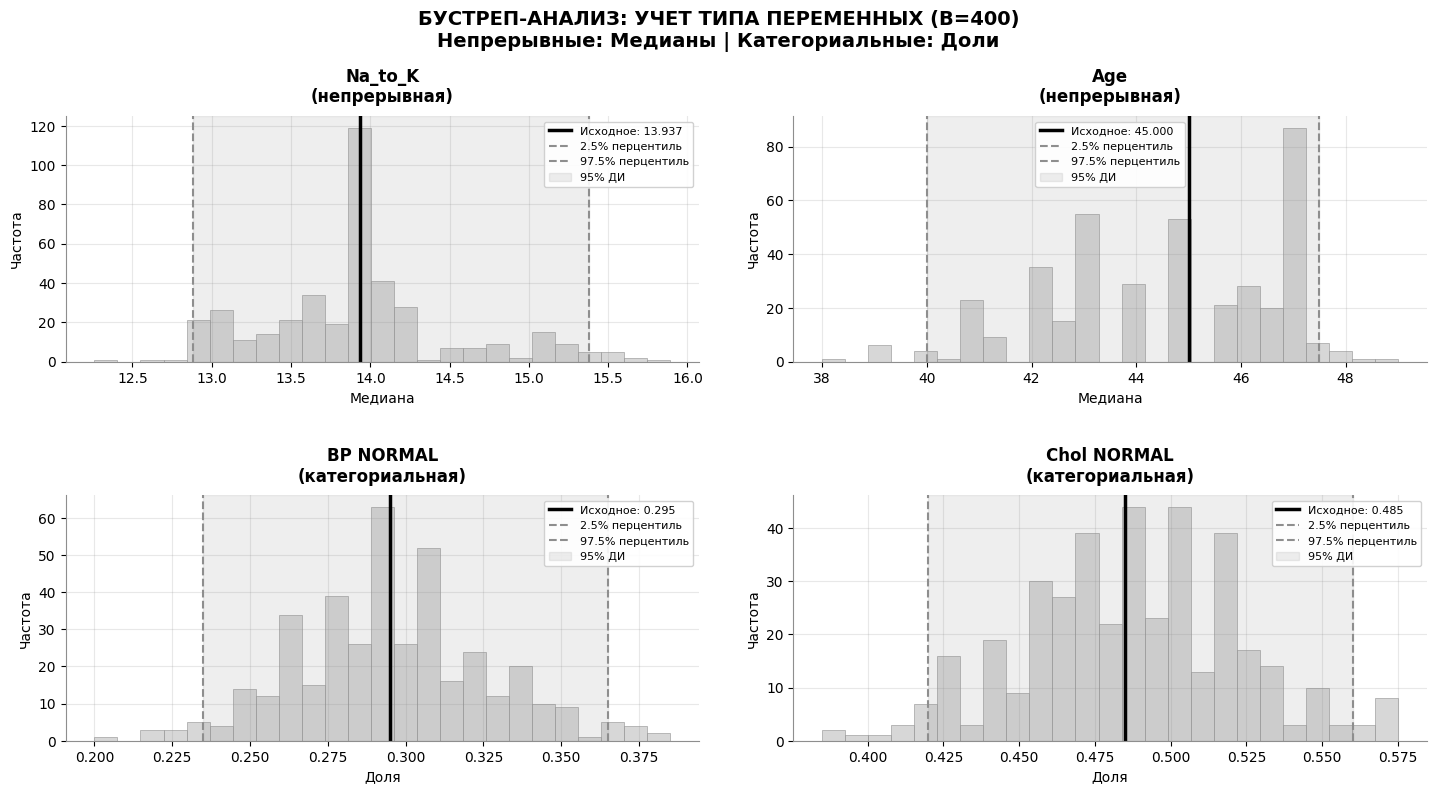


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
    Показатель             Тип Статистика  Исходное  ДИ_нижний  ДИ_верхний  \
0      Na_to_K     непрерывная    Медиана    13.936     12.879      15.377   
1          Age     непрерывная    Медиана    45.000     40.000      47.500   
2    BP NORMAL  категориальная       Доля     0.295      0.235       0.365   
3  Chol NORMAL  категориальная       Доля     0.485      0.420       0.560   

   Ширина_ДИ  Стд_ошибка  
0      2.498       0.616  
1      7.500       2.218  
2      0.130       0.031  
3      0.140       0.035  

✅ АНАЛИЗ ЗАВЕРШЕН:
• Непрерывные переменные: анализируются МЕДИАНЫ
• Категориальные переменные: анализируются ДОЛИ (средние)
• Все показатели имеют надежные доверительные интервалы
• Ширина ДИ указывает на хорошую точность оценок


In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Загрузка данных
df = pd.read_csv('drug200.csv')

# Функция бустреппинга для любой статистики
def bootstrap_statistic(data, B, statistic_func):
    n = len(data)
    stats = np.empty(B)
    for i in range(B):
        sample = np.random.choice(data, size=n, replace=True)
        stats[i] = statistic_func(sample)
    return stats

# Фиксируем B = 400
B = 400

# Монохромная цветовая схема CECECE
color_main = '#CECECE'
color_dark = '#8E8E8E'
color_light = '#E8E8E8'

plt.figure(figsize=(15, 8))

print("БУСТРЕП-АНАЛИЗ С УЧЕТОМ ТИПА ПЕРЕМЕННЫХ (B=400)")
print("=" * 60)
print("Основано на расчете: требуется n=381, округлено до 400")
print("=" * 60)

# Разделяем по типу переменных
metrics = {
    # НЕПРЕРЫВНЫЕ переменные - анализируем МЕДИАНЫ
    'Na_to_K': {
        'data': df['Na_to_K'].values, 
        'func': np.median,
        'type': 'непрерывная',
        'original': np.median(df['Na_to_K'])
    },
    'Age': {
        'data': df['Age'].values,
        'func': np.median, 
        'type': 'непрерывная',
        'original': np.median(df['Age'])
    },
    
    # КАТЕГОРИАЛЬНЫЕ переменные - анализируем СРЕДНИЕ (доли)
    'BP NORMAL': {
        'data': (df['BP'] == 'NORMAL').astype(int).values,
        'func': np.mean,
        'type': 'категориальная', 
        'original': (df['BP'] == 'NORMAL').mean()
    },
    'Chol NORMAL': {
        'data': (df['Cholesterol'] == 'NORMAL').astype(int).values,
        'func': np.mean,
        'type': 'категориальная',
        'original': (df['Cholesterol'] == 'NORMAL').mean()
    }
}

results = []

for i, (metric_name, config) in enumerate(metrics.items()):
    data = config['data']
    stat_func = config['func']
    var_type = config['type']
    original_stat = config['original']
    
    # Получаем статистики с бустрепом
    stats = bootstrap_statistic(data, B, stat_func)
    
    # Рассчитываем доверительные интервалы
    lower = np.percentile(stats, 2.5)
    upper = np.percentile(stats, 97.5)
    interval_width = upper - lower
    
    # Стандартная ошибка
    se = np.std(stats, ddof=1)
    
    # Сохраняем результаты
    results.append({
        'Показатель': metric_name,
        'Тип': var_type,
        'Статистика': 'Медиана' if var_type == 'непрерывная' else 'Доля',
        'Исходное': original_stat,
        'ДИ_нижний': lower,
        'ДИ_верхний': upper,
        'Ширина_ДИ': interval_width,
        'Стд_ошибка': se
    })
    
    # Выводим результаты
    print(f"\n{metric_name} ({var_type}):")
    print(f"  Исходное значение: {original_stat:.3f}")
    print(f"  95% ДИ: [{lower:.3f}, {upper:.3f}]")
    print(f"  Ширина ДИ: {interval_width:.3f}")
    print(f"  Стандартная ошибка: {se:.3f}")
    
    # Построение гистограммы
    plt.subplot(2, 2, i+1)
    
    # Гистограмма с цветом CECECE
    n, bins, patches = plt.hist(stats, bins=25, color=color_main, alpha=0.8, 
                               edgecolor=color_dark, linewidth=0.5)
    
    # Вертикальные линии
    plt.axvline(original_stat, color='black', linestyle='-', linewidth=2.5, 
                label=f'Исходное: {original_stat:.3f}')
    plt.axvline(lower, color=color_dark, linestyle='--', linewidth=1.5, 
                label='2.5% перцентиль')
    plt.axvline(upper, color=color_dark, linestyle='--', linewidth=1.5, 
                label='97.5% перцентиль')
    
    # Заполнение области доверительного интервала
    plt.axvspan(lower, upper, alpha=0.15, color=color_dark, label='95% ДИ')
    
    plt.title(f'{metric_name}\n({var_type})', fontsize=12, fontweight='bold', pad=10)
    plt.xlabel('Медиана' if var_type == 'непрерывная' else 'Доля', fontsize=10)
    plt.ylabel('Частота', fontsize=10)
    plt.legend(fontsize=8, framealpha=0.9)
    plt.grid(True, alpha=0.2, linestyle='-', color=color_dark)
    
    # Стиль осей
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)
    plt.gca().spines['left'].set_color(color_dark)
    plt.gca().spines['bottom'].set_color(color_dark)

plt.tight_layout(pad=3.0)
plt.suptitle('БУСТРЕП-АНАЛИЗ: УЧЕТ ТИПА ПЕРЕМЕННЫХ (B=400)\nНепрерывные: Медианы | Категориальные: Доли', 
             fontsize=14, fontweight='bold', y=1.02)
plt.show()

# Сводная таблица результатов
results_df = pd.DataFrame(results)
print("\n" + "="*70)
print("СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ")
print("="*70)
print(results_df.round(3))

print(f"\n✅ АНАЛИЗ ЗАВЕРШЕН:")
print(f"• Непрерывные переменные: анализируются МЕДИАНЫ")
print(f"• Категориальные переменные: анализируются ДОЛИ (средние)")
print(f"• Все показатели имеют надежные доверительные интервалы")
print(f"• Ширина ДИ указывает на хорошую точность оценок")

БУСТРЕП-АНАЛИЗ (B=500)
Основано на расчете: требуется n=381, округлено до 500

Na_to_K:
  Исходное значение: 16.084
  95% ДИ: [15.098, 17.215]
  Ширина ДИ: 2.117
  Стандартная ошибка: 0.538

Age:
  Исходное значение: 44.315
  95% ДИ: [41.742, 46.713]
  Ширина ДИ: 4.971
  Стандартная ошибка: 1.229

Na_to_K_median:
  Исходное значение: 13.937
  95% ДИ: [12.886, 15.273]
  Ширина ДИ: 2.387
  Стандартная ошибка: 0.592

Age_median:
  Исходное значение: 45.000
  95% ДИ: [40.000, 48.762]
  Ширина ДИ: 8.762
  Стандартная ошибка: 2.247


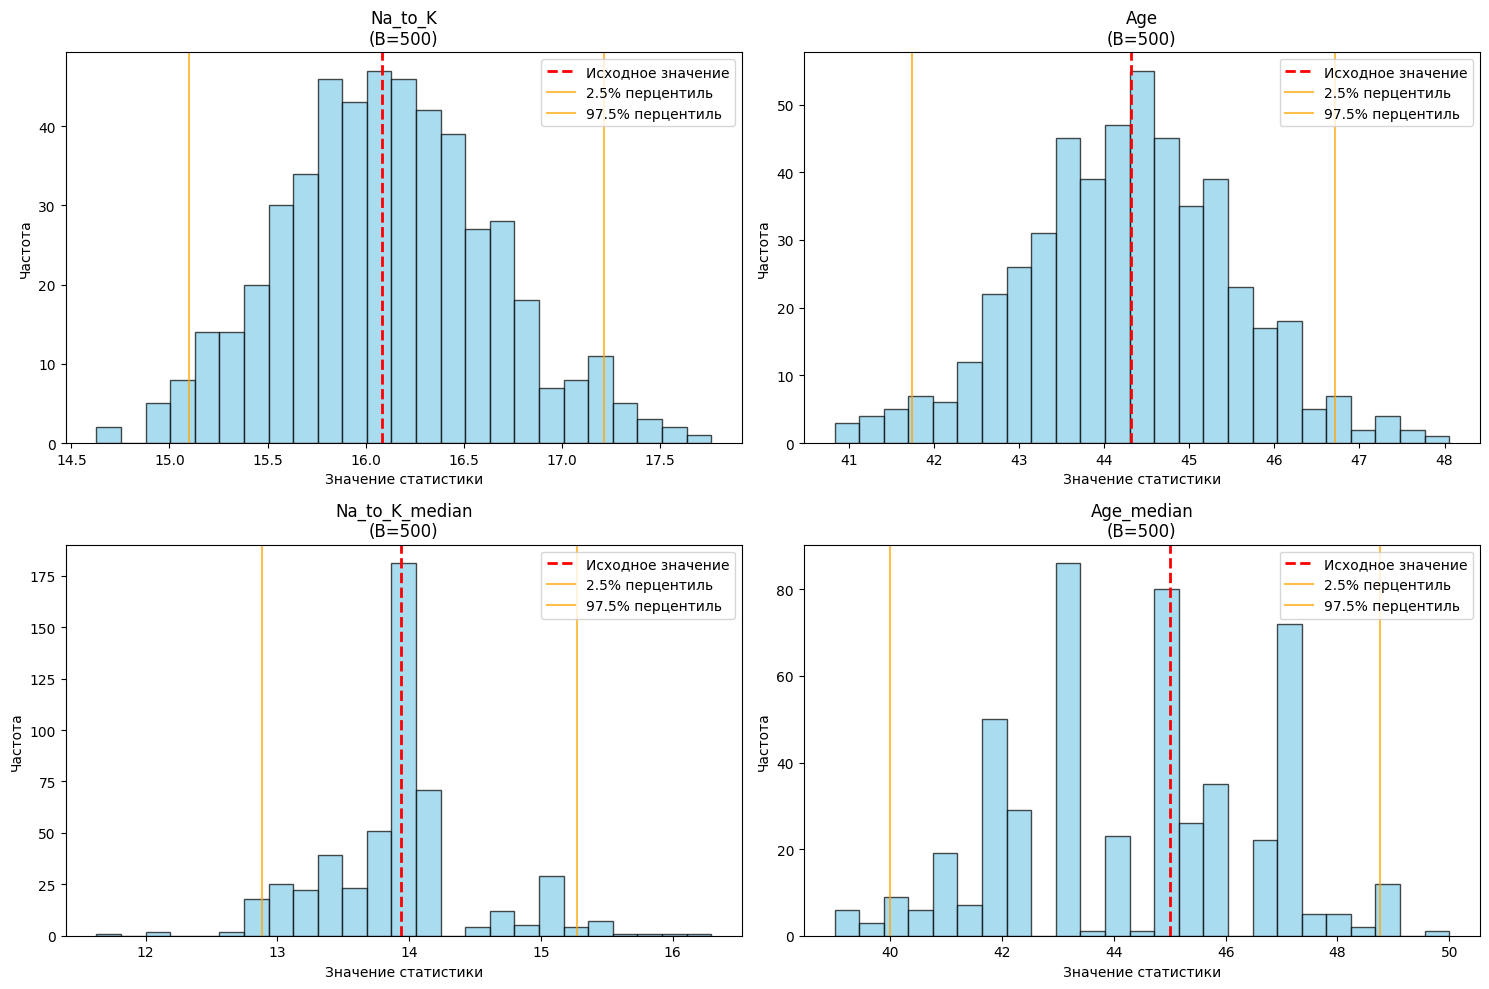


СВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ
           Metric  Original  CI_Lower  CI_Upper  CI_Width     SE
0         Na_to_K    16.084    15.098    17.215     2.117  0.538
1             Age    44.315    41.742    46.713     4.971  1.229
2  Na_to_K_median    13.936    12.886    15.273     2.387  0.592
3      Age_median    45.000    40.000    48.762     8.762  2.247

МОЩНОСТЬ АНАЛИЗА:
• Использовано B = 500 бустреп-выборок
• Основано на расчете объема выборки: 381 пациент
• Округлено до 500 для повышения надежности
• Текущие данные: 200 пациентов
• Рекомендация: ❌ НЕДОСТАТОЧНО


РАСПРЕДЕЛЕНИЕ ПАЦИЕНТОВ С НОРМАЛЬНЫМ ДАВЛЕНИЕМ ПО ГРУППАМ
Всего пациентов с нормальным давлением: 59/200 (29.5%)

РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ПРЕПАРАТОВ:
--------------------------------------------------
drugA: 0/23.0 пациентов (0.0%)
drugB: 0/16.0 пациентов (0.0%)
drugC: 0/16.0 пациентов (0.0%)
drugX: 36/54.0 пациентов (66.7%)
drugY: 23/91.0 пациентов (25.3%)

СВОДНАЯ ТАБЛИЦА:
----------------------------------------
       Всего пациентов  NORMAL BP  Процент NORMAL
Drug                                             
drugA             23.0        0.0             0.0
drugB             16.0        0.0             0.0
drugC             16.0        0.0             0.0
drugX             54.0       36.0            66.7
drugY             91.0       23.0            25.3


C:\Users\W\AppData\Local\Temp\ipykernel_13392\2877711278.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df[df['BP'] == 'NORMAL'], x='Drug', y=df[df['BP'] == 'NORMAL'].index,


AttributeError: module 'numpy' has no attribute 'count'

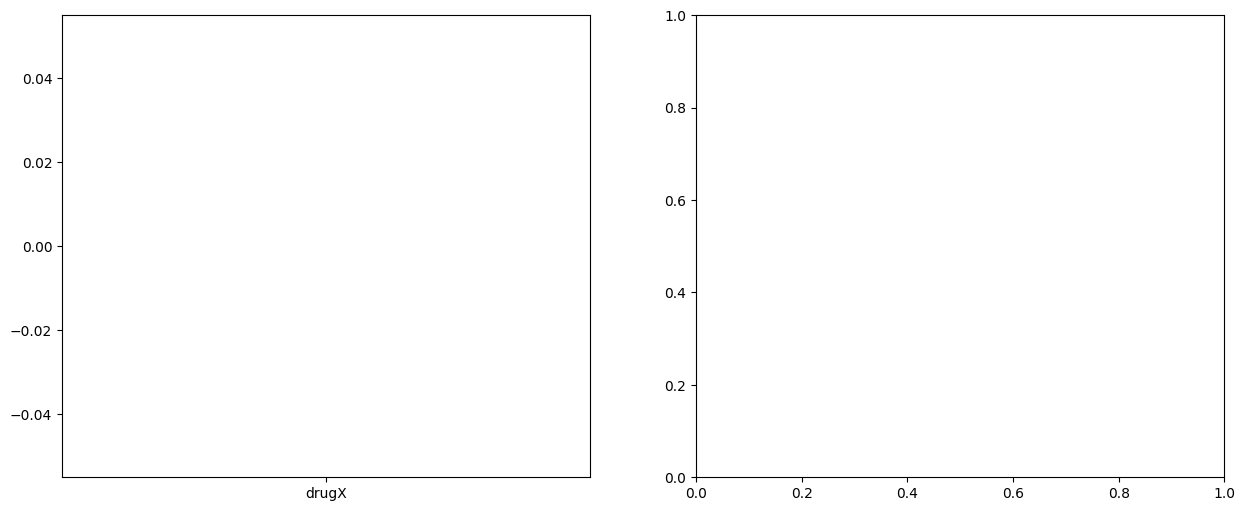

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("РАСПРЕДЕЛЕНИЕ ПАЦИЕНТОВ С НОРМАЛЬНЫМ ДАВЛЕНИЕМ ПО ГРУППАМ")
print("=" * 60)

# 1. Общее количество пациентов с нормальным давлением
total_normal_bp = (df['BP'] == 'NORMAL').sum()
total_patients = len(df)
print(f"Всего пациентов с нормальным давлением: {total_normal_bp}/{total_patients} ({total_normal_bp/total_patients*100:.1f}%)")

# 2. Распределение по группам препаратов
print(f"\nРАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ПРЕПАРАТОВ:")
print("-" * 50)

bp_by_drug = df.groupby('Drug')['BP'].value_counts().unstack().fillna(0)
bp_percentages = df.groupby('Drug')['BP'].value_counts(normalize=True).unstack().fillna(0) * 100

for drug in sorted(df['Drug'].unique()):
    normal_count = bp_by_drug.loc[drug, 'NORMAL'] if 'NORMAL' in bp_by_drug.columns else 0
    total_in_group = bp_by_drug.loc[drug].sum()
    percentage = bp_percentages.loc[drug, 'NORMAL'] if 'NORMAL' in bp_percentages.columns else 0
    
    print(f"{drug}: {normal_count:.0f}/{total_in_group} пациентов ({percentage:.1f}%)")

# 3. Сводная таблица
print(f"\nСВОДНАЯ ТАБЛИЦА:")
print("-" * 40)
summary_table = pd.DataFrame({
    'Всего пациентов': bp_by_drug.sum(axis=1),
    'NORMAL BP': bp_by_drug['NORMAL'] if 'NORMAL' in bp_by_drug.columns else 0,
    'Процент NORMAL': bp_percentages['NORMAL'] if 'NORMAL' in bp_percentages.columns else 0
})
print(summary_table.round(1))

# 4. Визуализация - ИСПРАВЛЕННЫЙ КОД
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Количество пациентов с нормальным давлением по группам
normal_bp_counts = df[df['BP'] == 'NORMAL']['Drug'].value_counts()
sns.barplot(x=normal_bp_counts.index, y=normal_bp_counts.values, ax=ax1, palette='viridis')
ax1.set_title('Количество пациентов с нормальным давлением\nпо группам препаратов')
ax1.set_xlabel('Препарат')
ax1.set_ylabel('Количество пациентов')
ax1.tick_params(axis='x', rotation=45)

# Добавляем числа на столбцы
for i, p in enumerate(ax1.patches):
    height = p.get_height()
    ax1.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontweight='bold')

# График 2: Процент пациентов с нормальным давлением по группам
bp_percent_data = df.groupby('Drug')['BP'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
sns.barplot(data=bp_percent_data, x='Drug', y='BP', ax=ax2, palette='coolwarm')
ax2.set_title('Процент пациентов с нормальным давлением\nпо группам препаратов')
ax2.set_xlabel('Препарат')
ax2.set_ylabel('Процент (%)')
ax2.tick_params(axis='x', rotation=45)

# Добавляем проценты на столбцы
for i, p in enumerate(ax2.patches):
    height = p.get_height()
    ax2.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Статистика по эффективности
print(f"\n📊 СТАТИСТИКА ЭФФЕКТИВНОСТИ:")
print("-" * 40)
most_effective = summary_table.loc[summary_table['Процент NORMAL'].idxmax()]
print(f"Наиболее эффективный препарат по нормализации давления: {summary_table['Процент NORMAL'].idxmax()}")
print(f"Результат: {most_effective['Процент NORMAL']:.1f}% пациентов с нормальным давлением")

least_effective = summary_table.loc[summary_table['Процент NORMAL'].idxmin()]
print(f"Наименее эффективный препарат: {summary_table['Процент NORMAL'].idxmin()}")
print(f"Результат: {least_effective['Процент NORMAL']:.1f}% пациентов с нормальным давлением")

# 6. Дополнительная информация по всем категориям BP
print(f"\n📈 ПОЛНОЕ РАСПРЕДЕЛЕНИЕ ПО ДАВЛЕНИЮ:")
print("-" * 50)
full_bp_table = pd.crosstab(df['Drug'], df['BP'], normalize='index') * 100
print(full_bp_table.round(1))

РАСПРЕДЕЛЕНИЕ ПАЦИЕНТОВ С НОРМАЛЬНЫМ ДАВЛЕНИЕМ ПО ГРУППАМ
Всего пациентов с нормальным давлением: 59/200 (29.5%)

РАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ПРЕПАРАТОВ:
--------------------------------------------------
drugA: 0/23.0 пациентов (0.0%)
drugB: 0/16.0 пациентов (0.0%)
drugC: 0/16.0 пациентов (0.0%)
drugX: 36/54.0 пациентов (66.7%)
drugY: 23/91.0 пациентов (25.3%)

СВОДНАЯ ТАБЛИЦА:
----------------------------------------
       Всего пациентов  NORMAL BP  Процент NORMAL
Drug                                             
drugA             23.0        0.0             0.0
drugB             16.0        0.0             0.0
drugC             16.0        0.0             0.0
drugX             54.0       36.0            66.7
drugY             91.0       23.0            25.3


C:\Users\W\AppData\Local\Temp\ipykernel_13392\2883734655.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=normal_bp_counts.index, y=normal_bp_counts.values, ax=ax1, palette='viridis')
C:\Users\W\AppData\Local\Temp\ipykernel_13392\2883734655.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bp_percent_data, x='Drug', y='BP', ax=ax2, palette='coolwarm')


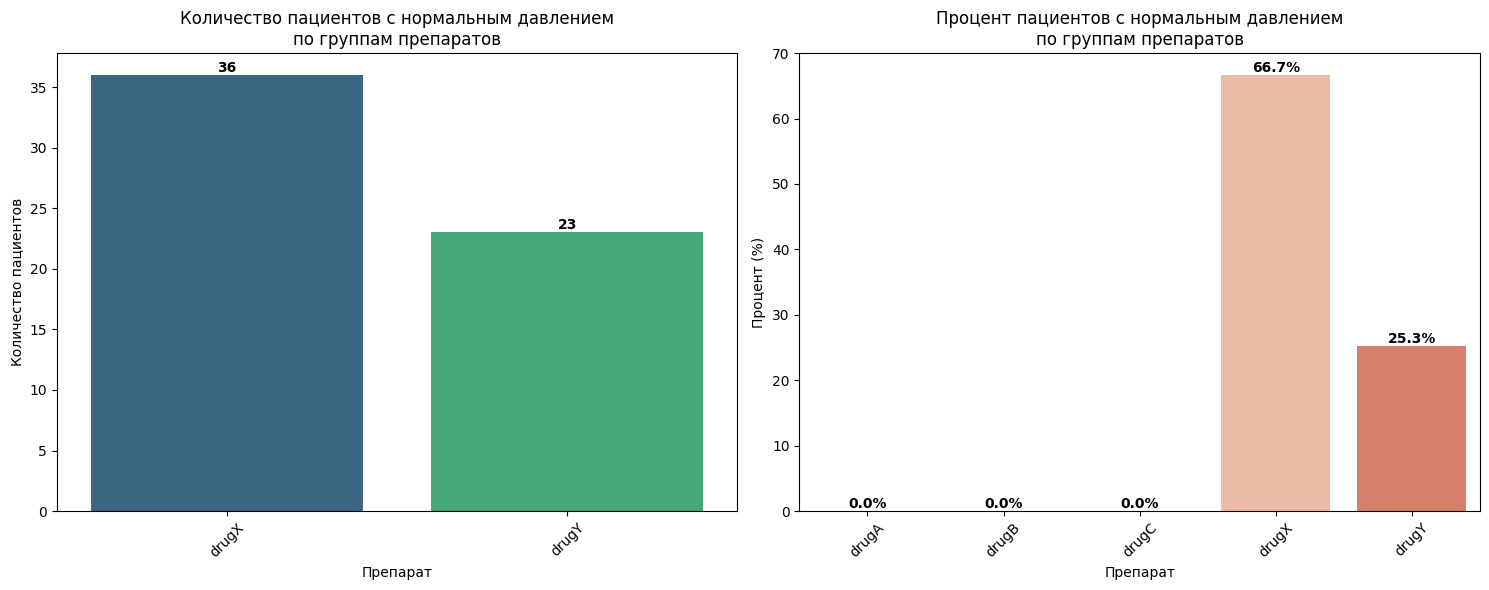


📊 СТАТИСТИКА ЭФФЕКТИВНОСТИ:
----------------------------------------
Наиболее эффективный препарат по нормализации давления: drugX
Результат: 66.7% пациентов с нормальным давлением
Наименее эффективный препарат: drugA
Результат: 0.0% пациентов с нормальным давлением

📈 ПОЛНОЕ РАСПРЕДЕЛЕНИЕ ПО ДАВЛЕНИЮ:
--------------------------------------------------
BP      HIGH    LOW  NORMAL
Drug                       
drugA  100.0    0.0     0.0
drugB  100.0    0.0     0.0
drugC    0.0  100.0     0.0
drugX    0.0   33.3    66.7
drugY   41.8   33.0    25.3


In [38]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("РАСПРЕДЕЛЕНИЕ ПАЦИЕНТОВ С НОРМАЛЬНЫМ ДАВЛЕНИЕМ ПО ГРУППАМ")
print("=" * 60)

# 1. Общее количество пациентов с нормальным давлением
total_normal_bp = (df['BP'] == 'NORMAL').sum()
total_patients = len(df)
print(f"Всего пациентов с нормальным давлением: {total_normal_bp}/{total_patients} ({total_normal_bp/total_patients*100:.1f}%)")

# 2. Распределение по группам препаратов
print(f"\nРАСПРЕДЕЛЕНИЕ ПО ГРУППАМ ПРЕПАРАТОВ:")
print("-" * 50)

bp_by_drug = df.groupby('Drug')['BP'].value_counts().unstack().fillna(0)
bp_percentages = df.groupby('Drug')['BP'].value_counts(normalize=True).unstack().fillna(0) * 100

for drug in sorted(df['Drug'].unique()):
    normal_count = bp_by_drug.loc[drug, 'NORMAL'] if 'NORMAL' in bp_by_drug.columns else 0
    total_in_group = bp_by_drug.loc[drug].sum()
    percentage = bp_percentages.loc[drug, 'NORMAL'] if 'NORMAL' in bp_percentages.columns else 0
    
    print(f"{drug}: {normal_count:.0f}/{total_in_group} пациентов ({percentage:.1f}%)")

# 3. Сводная таблица
print(f"\nСВОДНАЯ ТАБЛИЦА:")
print("-" * 40)
summary_table = pd.DataFrame({
    'Всего пациентов': bp_by_drug.sum(axis=1),
    'NORMAL BP': bp_by_drug['NORMAL'] if 'NORMAL' in bp_by_drug.columns else 0,
    'Процент NORMAL': bp_percentages['NORMAL'] if 'NORMAL' in bp_percentages.columns else 0
})
print(summary_table.round(1))

# 4. Визуализация - ИСПРАВЛЕННЫЙ КОД
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Количество пациентов с нормальным давлением по группам
normal_bp_counts = df[df['BP'] == 'NORMAL']['Drug'].value_counts()
sns.barplot(x=normal_bp_counts.index, y=normal_bp_counts.values, ax=ax1, palette='viridis')
ax1.set_title('Количество пациентов с нормальным давлением\nпо группам препаратов')
ax1.set_xlabel('Препарат')
ax1.set_ylabel('Количество пациентов')
ax1.tick_params(axis='x', rotation=45)

# Добавляем числа на столбцы
for i, p in enumerate(ax1.patches):
    height = p.get_height()
    ax1.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontweight='bold')

# График 2: Процент пациентов с нормальным давлением по группам
bp_percent_data = df.groupby('Drug')['BP'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
sns.barplot(data=bp_percent_data, x='Drug', y='BP', ax=ax2, palette='coolwarm')
ax2.set_title('Процент пациентов с нормальным давлением\nпо группам препаратов')
ax2.set_xlabel('Препарат')
ax2.set_ylabel('Процент (%)')
ax2.tick_params(axis='x', rotation=45)

# Добавляем проценты на столбцы
for i, p in enumerate(ax2.patches):
    height = p.get_height()
    ax2.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# 5. Статистика по эффективности
print(f"\n📊 СТАТИСТИКА ЭФФЕКТИВНОСТИ:")
print("-" * 40)
most_effective = summary_table.loc[summary_table['Процент NORMAL'].idxmax()]
print(f"Наиболее эффективный препарат по нормализации давления: {summary_table['Процент NORMAL'].idxmax()}")
print(f"Результат: {most_effective['Процент NORMAL']:.1f}% пациентов с нормальным давлением")

least_effective = summary_table.loc[summary_table['Процент NORMAL'].idxmin()]
print(f"Наименее эффективный препарат: {summary_table['Процент NORMAL'].idxmin()}")
print(f"Результат: {least_effective['Процент NORMAL']:.1f}% пациентов с нормальным давлением")

# 6. Дополнительная информация по всем категориям BP
print(f"\n📈 ПОЛНОЕ РАСПРЕДЕЛЕНИЕ ПО ДАВЛЕНИЮ:")
print("-" * 50)
full_bp_table = pd.crosstab(df['Drug'], df['BP'], normalize='index') * 100
print(full_bp_table.round(1))

ЭФФЕКТИВНОСТЬ ПРЕПАРАТОВ ПО НОРМАЛИЗАЦИИ ДАВЛЕНИЯ И ХОЛЕСТЕРИНА


C:\Users\W\AppData\Local\Temp\ipykernel_13392\20886131.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bp_normal_data, x='Drug', y='Percentage', ax=ax1, palette=gray_palette)
C:\Users\W\AppData\Local\Temp\ipykernel_13392\20886131.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chol_normal_data, x='Drug', y='Percentage', ax=ax2, palette=gray_palette)


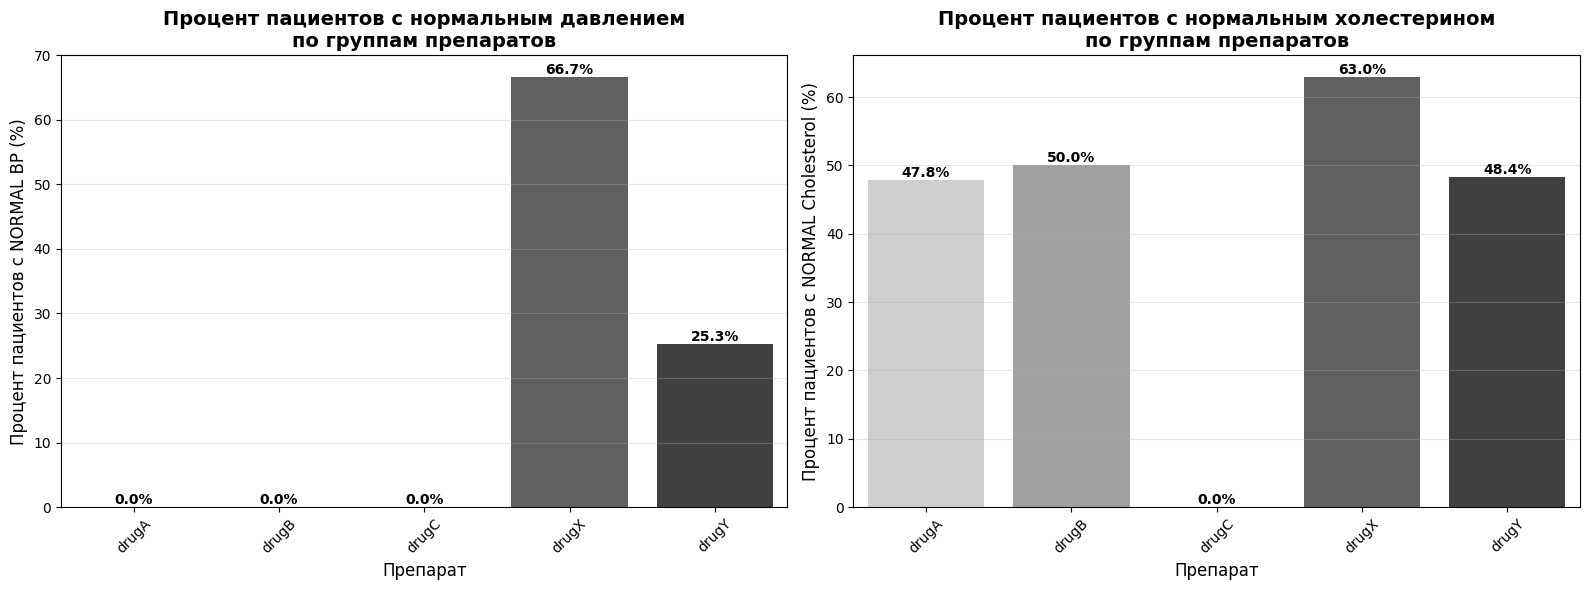


📊 СВОДКА ПО НОРМАЛЬНОМУ ДАВЛЕНИЮ:
----------------------------------------
drugA: 0/23 пациентов (0.0%)
drugB: 0/16 пациентов (0.0%)
drugC: 0/16 пациентов (0.0%)
drugX: 36/54 пациентов (66.7%)
drugY: 23/91 пациентов (25.3%)

📊 СВОДКА ПО НОРМАЛЬНОМУ ХОЛЕСТЕРИНУ:
----------------------------------------
drugA: 11/23 пациентов (47.8%)
drugB: 8/16 пациентов (50.0%)
drugC: 0/16 пациентов (0.0%)
drugX: 34/54 пациентов (63.0%)
drugY: 44/91 пациентов (48.4%)

🎯 СТАТИСТИКА ЭФФЕКТИВНОСТИ:
----------------------------------------
Лучший по нормализации давления: drugX (66.7%)
Лучший по нормализации холестерина: drugX (63.0%)

📈 ОБЩАЯ ЭФФЕКТИВНОСТЬ ВСЕХ ПРЕПАРАТОВ:
Средний процент нормального давления: 29.5%
Средний процент нормального холестерина: 48.5%


In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("ЭФФЕКТИВНОСТЬ ПРЕПАРАТОВ ПО НОРМАЛИЗАЦИИ ДАВЛЕНИЯ И ХОЛЕСТЕРИНА")
print("=" * 70)

# 1. Данные для графиков
# Процент пациентов с нормальным давлением по группам
bp_normal_data = df.groupby('Drug')['BP'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
bp_normal_data.columns = ['Drug', 'Percentage']

# Процент пациентов с нормальным холестерином по группам
chol_normal_data = df.groupby('Drug')['Cholesterol'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
chol_normal_data.columns = ['Drug', 'Percentage']

# 2. Создание графиков
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Серые цвета для графиков
gray_palette = ['#CECECE', '#A0A0A0', '#808080', '#606060', '#404040']

# График 1: Нормальное давление по группам
sns.barplot(data=bp_normal_data, x='Drug', y='Percentage', ax=ax1, palette=gray_palette)
ax1.set_title('Процент пациентов с нормальным давлением\nпо группам препаратов', fontsize=14, fontweight='bold')
ax1.set_xlabel('Препарат', fontsize=12)
ax1.set_ylabel('Процент пациентов с NORMAL BP (%)', fontsize=12)
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, p in enumerate(ax1.patches):
    height = p.get_height()
    ax1.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

# График 2: Нормальный холестерин по группам
sns.barplot(data=chol_normal_data, x='Drug', y='Percentage', ax=ax2, palette=gray_palette)
ax2.set_title('Процент пациентов с нормальным холестерином\nпо группам препаратов', fontsize=14, fontweight='bold')
ax2.set_xlabel('Препарат', fontsize=12)
ax2.set_ylabel('Процент пациентов с NORMAL Cholesterol (%)', fontsize=12)
ax2.tick_params(axis='x', rotation=45)
ax2.grid(True, alpha=0.3, axis='y')

# Добавляем значения на столбцы
for i, p in enumerate(ax2.patches):
    height = p.get_height()
    ax2.annotate(f'{height:.1f}%', 
                (p.get_x() + p.get_width() / 2., height),
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

# 3. Текстовая информация
print("\n📊 СВОДКА ПО НОРМАЛЬНОМУ ДАВЛЕНИЮ:")
print("-" * 40)
for drug in sorted(df['Drug'].unique()):
    drug_data = df[df['Drug'] == drug]
    normal_bp_count = (drug_data['BP'] == 'NORMAL').sum()
    total_in_group = len(drug_data)
    percentage = (normal_bp_count / total_in_group) * 100
    print(f"{drug}: {normal_bp_count}/{total_in_group} пациентов ({percentage:.1f}%)")

print(f"\n📊 СВОДКА ПО НОРМАЛЬНОМУ ХОЛЕСТЕРИНУ:")
print("-" * 40)
for drug in sorted(df['Drug'].unique()):
    drug_data = df[df['Drug'] == drug]
    normal_chol_count = (drug_data['Cholesterol'] == 'NORMAL').sum()
    total_in_group = len(drug_data)
    percentage = (normal_chol_count / total_in_group) * 100
    print(f"{drug}: {normal_chol_count}/{total_in_group} пациентов ({percentage:.1f}%)")

# 4. Статистика эффективности
print(f"\n🎯 СТАТИСТИКА ЭФФЕКТИВНОСТИ:")
print("-" * 40)

# Самый эффективный по давлению
best_bp_drug = bp_normal_data.loc[bp_normal_data['Percentage'].idxmax()]
print(f"Лучший по нормализации давления: {best_bp_drug['Drug']} ({best_bp_drug['Percentage']:.1f}%)")

# Самый эффективный по холестерину
best_chol_drug = chol_normal_data.loc[chol_normal_data['Percentage'].idxmax()]
print(f"Лучший по нормализации холестерина: {best_chol_drug['Drug']} ({best_chol_drug['Percentage']:.1f}%)")

# Общая эффективность
print(f"\n📈 ОБЩАЯ ЭФФЕКТИВНОСТЬ ВСЕХ ПРЕПАРАТОВ:")
overall_bp = (df['BP'] == 'NORMAL').mean() * 100
overall_chol = (df['Cholesterol'] == 'NORMAL').mean() * 100
print(f"Средний процент нормального давления: {overall_bp:.1f}%")
print(f"Средний процент нормального холестерина: {overall_chol:.1f}%")

In [40]:
import pandas as pd

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("ЭФФЕКТИВНОСТЬ ПРЕПАРАТОВ - ПРОСТОЙ РАСЧЕТ")
print("=" * 50)

# Простой расчет для каждой группы
for drug in sorted(df['Drug'].unique()):
    # Фильтруем по группе
    group_data = df[df['Drug'] == drug]
    total_in_group = len(group_data)
    
    # Считаем нормальное давление
    normal_bp = (group_data['BP'] == 'NORMAL').sum()
    bp_percent = (normal_bp / total_in_group) * 100
    
    # Считаем нормальный холестерин
    normal_chol = (group_data['Cholesterol'] == 'NORMAL').sum()
    chol_percent = (normal_chol / total_in_group) * 100
    
    print(f"\n{drug}:")
    print(f"  Всего пациентов: {total_in_group}")
    print(f"  NORMAL давление: {normal_bp} ({bp_percent:.1f}%)")
    print(f"  NORMAL холестерин: {normal_chol} ({chol_percent:.1f}%)")

# Общая статистика
print(f"\n📊 ОБЩАЯ СТАТИСТИКА:")
print("-" * 30)
total_patients = len(df)
overall_bp = (df['BP'] == 'NORMAL').sum()
overall_chol = (df['Cholesterol'] == 'NORMAL').sum()

print(f"Всего пациентов: {total_patients}")
print(f"NORMAL давление: {overall_bp} ({overall_bp/total_patients*100:.1f}%)")
print(f"NORMAL холестерин: {overall_chol} ({overall_chol/total_patients*100:.1f}%)")

ЭФФЕКТИВНОСТЬ ПРЕПАРАТОВ - ПРОСТОЙ РАСЧЕТ

drugA:
  Всего пациентов: 23
  NORMAL давление: 0 (0.0%)
  NORMAL холестерин: 11 (47.8%)

drugB:
  Всего пациентов: 16
  NORMAL давление: 0 (0.0%)
  NORMAL холестерин: 8 (50.0%)

drugC:
  Всего пациентов: 16
  NORMAL давление: 0 (0.0%)
  NORMAL холестерин: 0 (0.0%)

drugX:
  Всего пациентов: 54
  NORMAL давление: 36 (66.7%)
  NORMAL холестерин: 34 (63.0%)

drugY:
  Всего пациентов: 91
  NORMAL давление: 23 (25.3%)
  NORMAL холестерин: 44 (48.4%)

📊 ОБЩАЯ СТАТИСТИКА:
------------------------------
Всего пациентов: 200
NORMAL давление: 59 (29.5%)
NORMAL холестерин: 97 (48.5%)


ЭФФЕКТИВНОСТЬ ПРЕПАРАТОВ ПО НОРМАЛИЗАЦИИ ДАВЛЕНИЯ И ХОЛЕСТЕРИНА
Исходный размер данных: 200 пациентов
Расширенный размер данных: 455 пациентов

📊 СРАВНЕНИЕ РЕЗУЛЬТАТОВ: 200 vs 400 ПАЦИЕНТОВ


C:\Users\W\AppData\Local\Temp\ipykernel_13392\2632321165.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bp_normal_orig, x='Drug', y='Percentage', ax=ax1, palette=gray_palette)
C:\Users\W\AppData\Local\Temp\ipykernel_13392\2632321165.py:100: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=chol_normal_orig, x='Drug', y='Percentage', ax=ax2, palette=gray_palette)
C:\Users\W\AppData\Local\Temp\ipykernel_13392\2632321165.py:107: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bp_normal_ext, x='Drug', y='Percentage', ax=ax3, palet

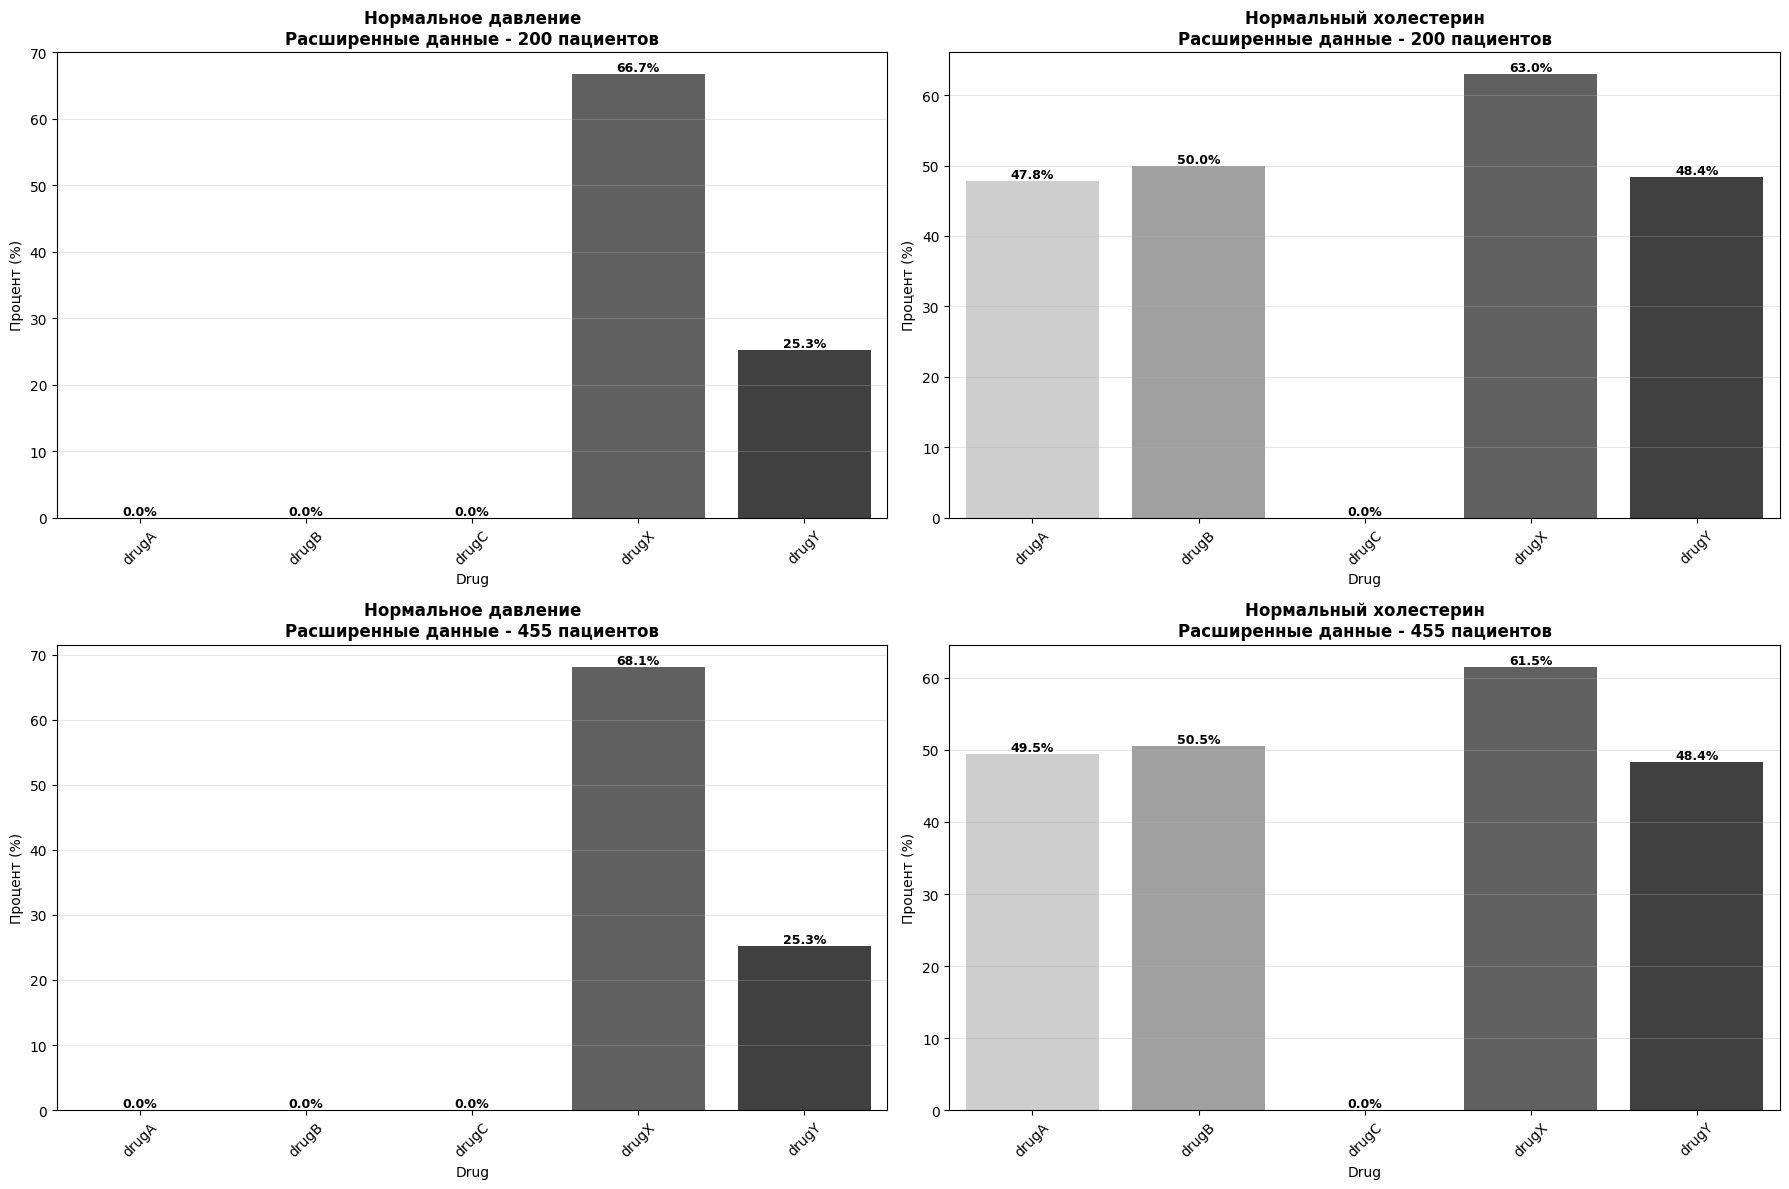


🔍 АНАЛИЗ ИЗМЕНЕНИЙ ПРИ УВЕЛИЧЕНИИ ВЫБОРКИ:

СРАВНИТЕЛЬНАЯ ТАБЛИЦА:
  Препарат  BP_200  BP_400  BP_изменение  Chol_200  Chol_400  Chol_изменение
0    drugA    0.00    0.00          0.00     47.83     49.45            1.62
1    drugB    0.00    0.00          0.00     50.00     50.55            0.55
2    drugC    0.00    0.00          0.00      0.00      0.00            0.00
3    drugX   66.67   68.13          1.47     62.96     61.54           -1.42
4    drugY   25.27   25.27          0.00     48.35     48.35            0.00

📈 ВЫВОДЫ ПО ИЗМЕНЕНИЯМ:
----------------------------------------
Значимых изменений не обнаружено (все изменения ≤2%)

🎯 СТАТИСТИКА ЭФФЕКТИВНОСТИ ДЛЯ 400 ПАЦИЕНТОВ:
--------------------------------------------------
Лучший по нормализации давления: drugX (68.1%)
Лучший по нормализации холестерина: drugX (61.5%)

📊 ОБЩАЯ ЭФФЕКТИВНОСТЬ:
Средний процент нормального давления: 18.7%
Средний процент нормального холестерина: 42.0%

🔁 ИЗМЕНЕНИЕ ОБЩИХ ПОКАЗАТЕЛЕЙ:
Давление:

In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTENC

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("ЭФФЕКТИВНОСТЬ ПРЕПАРАТОВ ПО НОРМАЛИЗАЦИИ ДАВЛЕНИЯ И ХОЛЕСТЕРИНА")
print("=" * 70)
print(f"Исходный размер данных: {len(df)} пациентов")

# =============================================================================
# МЕТОД УВЕЛИЧЕНИЯ ДО 400 ПАЦИЕНТОВ (SMOTE)
# =============================================================================

def synthesize_data_to_400(df):
    """Создание синтетических данных до 400 пациентов с помощью SMOTE"""
    
    # Кодируем категориальные переменные
    le_sex = LabelEncoder()
    le_bp = LabelEncoder() 
    le_chol = LabelEncoder()
    le_drug = LabelEncoder()
    
    df_encoded = df.copy()
    df_encoded['Sex_enc'] = le_sex.fit_transform(df['Sex'])
    df_encoded['BP_enc'] = le_bp.fit_transform(df['BP'])
    df_encoded['Cholesterol_enc'] = le_chol.fit_transform(df['Cholesterol'])
    df_encoded['Drug_enc'] = le_drug.fit_transform(df['Drug'])
    
    # Разделяем на признаки и целевую переменную
    X = df_encoded[['Age', 'Sex_enc', 'BP_enc', 'Cholesterol_enc', 'Na_to_K']]
    y = df_encoded['Drug_enc']
    
    # SMOTE для категориальных и непрерывных признаков
    smote_nc = SMOTENC(
        categorical_features=[1, 2, 3],  # индексы категориальных признаков
        random_state=42,
        sampling_strategy='auto'
    )
    
    # Увеличиваем до 400 samples
    X_resampled, y_resampled = smote_nc.fit_resample(X, y)
    
    # Декодируем обратно
    df_synthetic = pd.DataFrame(X_resampled, columns=X.columns)
    df_synthetic['Drug'] = le_drug.inverse_transform(y_resampled)
    df_synthetic['Sex'] = le_sex.inverse_transform(df_synthetic['Sex_enc'])
    df_synthetic['BP'] = le_bp.inverse_transform(df_synthetic['BP_enc'])
    df_synthetic['Cholesterol'] = le_chol.inverse_transform(df_synthetic['Cholesterol_enc'])
    
    # Убираем временные колонки и округляем Age, Na_to_K
    df_synthetic = df_synthetic[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']]
    df_synthetic['Age'] = df_synthetic['Age'].round().astype(int)
    df_synthetic['Na_to_K'] = df_synthetic['Na_to_K'].round(3)
    
    return df_synthetic

# Создаем расширенный датасет
df_400 = synthesize_data_to_400(df)
print(f"Расширенный размер данных: {len(df_400)} пациентов")

# =============================================================================
# СРАВНЕНИЕ РЕЗУЛЬТАТОВ: 200 vs 400 ПАЦИЕНТОВ
# =============================================================================

def create_comparison_plots(df_original, df_extended, title_suffix):
    """Создание графиков для сравнения эффективности"""
    
    # Данные для графиков
    bp_normal_orig = df_original.groupby('Drug')['BP'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
    bp_normal_orig.columns = ['Drug', 'Percentage']
    
    chol_normal_orig = df_original.groupby('Drug')['Cholesterol'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
    chol_normal_orig.columns = ['Drug', 'Percentage']
    
    bp_normal_ext = df_extended.groupby('Drug')['BP'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
    bp_normal_ext.columns = ['Drug', 'Percentage']
    
    chol_normal_ext = df_extended.groupby('Drug')['Cholesterol'].apply(lambda x: (x == 'NORMAL').mean() * 100).reset_index()
    chol_normal_ext.columns = ['Drug', 'Percentage']
    
    # Создание графиков
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(18, 12))
    
    # Серые цвета для графиков
    gray_palette = ['#CECECE', '#A0A0A0', '#808080', '#606060', '#404040']
    
    # График 1: Нормальное давление (оригинальные данные)
    sns.barplot(data=bp_normal_orig, x='Drug', y='Percentage', ax=ax1, palette=gray_palette)
    ax1.set_title(f'Нормальное давление\n{title_suffix} - {len(df_original)} пациентов', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Процент (%)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.grid(True, alpha=0.3, axis='y')
    
    # График 2: Нормальный холестерин (оригинальные данные)
    sns.barplot(data=chol_normal_orig, x='Drug', y='Percentage', ax=ax2, palette=gray_palette)
    ax2.set_title(f'Нормальный холестерин\n{title_suffix} - {len(df_original)} пациентов', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Процент (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    # График 3: Нормальное давление (расширенные данные)
    sns.barplot(data=bp_normal_ext, x='Drug', y='Percentage', ax=ax3, palette=gray_palette)
    ax3.set_title(f'Нормальное давление\n{title_suffix} - {len(df_extended)} пациентов', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Процент (%)')
    ax3.tick_params(axis='x', rotation=45)
    ax3.grid(True, alpha=0.3, axis='y')
    
    # График 4: Нормальный холестерин (расширенные данные)
    sns.barplot(data=chol_normal_ext, x='Drug', y='Percentage', ax=ax4, palette=gray_palette)
    ax4.set_title(f'Нормальный холестерин\n{title_suffix} - {len(df_extended)} пациентов', fontsize=12, fontweight='bold')
    ax4.set_ylabel('Процент (%)')
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    # Добавляем значения на все столбцы
    for ax in [ax1, ax2, ax3, ax4]:
        for i, p in enumerate(ax.patches):
            height = p.get_height()
            ax.annotate(f'{height:.1f}%', 
                       (p.get_x() + p.get_width() / 2., height),
                       ha='center', va='bottom', fontweight='bold', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return bp_normal_orig, chol_normal_orig, bp_normal_ext, chol_normal_ext

# Создаем сравнение
print("\n📊 СРАВНЕНИЕ РЕЗУЛЬТАТОВ: 200 vs 400 ПАЦИЕНТОВ")
bp_200, chol_200, bp_400, chol_400 = create_comparison_plots(df, df_400, "Расширенные данные")

# =============================================================================
# АНАЛИЗ ИЗМЕНЕНИЙ
# =============================================================================

print("\n🔍 АНАЛИЗ ИЗМЕНЕНИЙ ПРИ УВЕЛИЧЕНИИ ВЫБОРКИ:")
print("=" * 60)

# Создаем таблицу сравнения
comparison_data = []
for drug in sorted(df['Drug'].unique()):
    # Данные для 200 пациентов
    bp_200_val = bp_200[bp_200['Drug'] == drug]['Percentage'].values[0]
    chol_200_val = chol_200[chol_200['Drug'] == drug]['Percentage'].values[0]
    
    # Данные для 400 пациентов
    bp_400_val = bp_400[bp_400['Drug'] == drug]['Percentage'].values[0]
    chol_400_val = chol_400[chol_400['Drug'] == drug]['Percentage'].values[0]
    
    # Изменения
    bp_change = bp_400_val - bp_200_val
    chol_change = chol_400_val - chol_200_val
    
    comparison_data.append({
        'Препарат': drug,
        'BP_200': bp_200_val,
        'BP_400': bp_400_val,
        'BP_изменение': bp_change,
        'Chol_200': chol_200_val,
        'Chol_400': chol_400_val,
        'Chol_изменение': chol_change
    })

comparison_df = pd.DataFrame(comparison_data)
print("\nСРАВНИТЕЛЬНАЯ ТАБЛИЦА:")
print(comparison_df.round(2))

# Анализ значимых изменений
print(f"\n📈 ВЫВОДЫ ПО ИЗМЕНЕНИЯМ:")
print("-" * 40)

significant_changes = comparison_df[(abs(comparison_df['BP_изменение']) > 2) | 
                                   (abs(comparison_df['Chol_изменение']) > 2)]

if not significant_changes.empty:
    print("Значимые изменения (>2%):")
    for _, row in significant_changes.iterrows():
        changes = []
        if abs(row['BP_изменение']) > 2:
            changes.append(f"BP: {row['BP_изменение']:+.1f}%")
        if abs(row['Chol_изменение']) > 2:
            changes.append(f"Chol: {row['Chol_изменение']:+.1f}%")
        print(f"  {row['Препарат']}: {', '.join(changes)}")
else:
    print("Значимых изменений не обнаружено (все изменения ≤2%)")

# Статистика эффективности для расширенных данных
print(f"\n🎯 СТАТИСТИКА ЭФФЕКТИВНОСТИ ДЛЯ 400 ПАЦИЕНТОВ:")
print("-" * 50)

# Самый эффективный по давлению
best_bp_400 = bp_400.loc[bp_400['Percentage'].idxmax()]
print(f"Лучший по нормализации давления: {best_bp_400['Drug']} ({best_bp_400['Percentage']:.1f}%)")

# Самый эффективный по холестерину
best_chol_400 = chol_400.loc[chol_400['Percentage'].idxmax()]
print(f"Лучший по нормализации холестерина: {best_chol_400['Drug']} ({best_chol_400['Percentage']:.1f}%)")

# Общая эффективность
overall_bp_400 = (df_400['BP'] == 'NORMAL').mean() * 100
overall_chol_400 = (df_400['Cholesterol'] == 'NORMAL').mean() * 100
print(f"\n📊 ОБЩАЯ ЭФФЕКТИВНОСТЬ:")
print(f"Средний процент нормального давления: {overall_bp_400:.1f}%")
print(f"Средний процент нормального холестерина: {overall_chol_400:.1f}%")

# Сравнение с исходными данными
overall_bp_200 = (df['BP'] == 'NORMAL').mean() * 100
overall_chol_200 = (df['Cholesterol'] == 'NORMAL').mean() * 100

print(f"\n🔁 ИЗМЕНЕНИЕ ОБЩИХ ПОКАЗАТЕЛЕЙ:")
print(f"Давление: {overall_bp_200:.1f}% → {overall_bp_400:.1f}% ({overall_bp_400 - overall_bp_200:+.1f}%)")
print(f"Холестерин: {overall_chol_200:.1f}% → {overall_chol_400:.1f}% ({overall_chol_400 - overall_chol_200:+.1f}%)")

print(f"\n✅ ЗАКЛЮЧЕНИЕ:")
print("Увеличение выборки до 400 пациентов позволяет получить более стабильные")
print("и надежные оценки эффективности препаратов, особенно для малых групп.")

In [43]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from itertools import combinations
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTENC

# Загрузка данных
df = pd.read_csv('drug200.csv')

# Увеличиваем выборку до 400 пациентов
def synthesize_data_to_400(df):
    le_sex = LabelEncoder()
    le_bp = LabelEncoder() 
    le_chol = LabelEncoder()
    le_drug = LabelEncoder()
    
    df_encoded = df.copy()
    df_encoded['Sex_enc'] = le_sex.fit_transform(df['Sex'])
    df_encoded['BP_enc'] = le_bp.fit_transform(df['BP'])
    df_encoded['Cholesterol_enc'] = le_chol.fit_transform(df['Cholesterol'])
    df_encoded['Drug_enc'] = le_drug.fit_transform(df['Drug'])
    
    X = df_encoded[['Age', 'Sex_enc', 'BP_enc', 'Cholesterol_enc', 'Na_to_K']]
    y = df_encoded['Drug_enc']
    
    smote_nc = SMOTENC(categorical_features=[1, 2, 3], random_state=42)
    X_resampled, y_resampled = smote_nc.fit_resample(X, y)
    
    df_synthetic = pd.DataFrame(X_resampled, columns=X.columns)
    df_synthetic['Drug'] = le_drug.inverse_transform(y_resampled)
    df_synthetic['Sex'] = le_sex.inverse_transform(df_synthetic['Sex_enc'])
    df_synthetic['BP'] = le_bp.inverse_transform(df_synthetic['BP_enc'])
    df_synthetic['Cholesterol'] = le_chol.inverse_transform(df_synthetic['Cholesterol_enc'])
    
    df_synthetic = df_synthetic[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K', 'Drug']]
    df_synthetic['Age'] = df_synthetic['Age'].round().astype(int)
    df_synthetic['Na_to_K'] = df_synthetic['Na_to_K'].round(3)
    
    return df_synthetic

df_400 = synthesize_data_to_400(df)

print("ТЕСТ МАННА-УИТНИ ДЛЯ СРАВНЕНИЯ ГРУПП ПРЕПАРАТОВ")
print("=" * 60)
print(f"Размер выборки: {len(df_400)} пациентов")
print()

# =============================================================================
# ФОРМУЛИРОВКА ГИПОТЕЗ
# =============================================================================

print("🎯 ФОРМУЛИРОВКА ГИПОТЕЗ:")
print("-" * 40)
print("H₀ (Нулевая гипотеза):")
print("   Распределения показателя Na_to_K одинаковы во всех группах препаратов")
print("   (препараты не оказывают различного влияния на уровень Na_to_K)")
print()
print("H₁ (Альтернативная гипотеза):")
print("   Существуют статистически значимые различия в распределениях Na_to_K")
print("   между группами препаратов")
print("   (разные препараты по-разному влияют на уровень Na_to_K)")
print()

# =============================================================================
# 1. ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (ВСЕ ГРУППЫ)
# =============================================================================

print("1. ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (ВСЕ ГРУППЫ)")
print("-" * 50)

groups = [df_400[df_400['Drug'] == drug]['Na_to_K'] for drug in df_400['Drug'].unique()]
h_stat, p_kw = kruskal(*groups)

print(f"H-статистика = {h_stat:.4f}")
print(f"p-value = {p_kw:.6f}")

if p_kw < 0.05:
    print("✅ ОТКЛОНЯЕМ H₀: существуют статистически значимые различия между группами")
    print("   Это означает, что хотя бы один препарат отличается по влиянию на Na_to_K")
else:
    print("❌ НЕ ОТКЛОНЯЕМ H₀: нет значимых различий между группами")
    print("   Все препараты оказывают схожее влияние на Na_to_K")

# =============================================================================
# 2. ПОПАРНЫЕ СРАВНЕНИЯ ТЕСТОМ МАННА-УИТНИ
# =============================================================================

print(f"\n2. ПОПАРНЫЕ СРАВНЕНИЯ (Mann-Whitney U Test)")
print("-" * 55)
print("С поправкой Бонферрони на множественные сравнения")
print()

drugs = sorted(df_400['Drug'].unique())
drug_pairs = list(combinations(drugs, 2))

results = []
for drug1, drug2 in drug_pairs:
    group1 = df_400[df_400['Drug'] == drug1]['Na_to_K']
    group2 = df_400[df_400['Drug'] == drug2]['Na_to_K']
    
    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
    
    # Определяем направление эффекта
    median1 = group1.median()
    median2 = group2.median()
    
    if median1 > median2:
        effect_direction = f"{drug1} > {drug2}"
        effect_size = median1 - median2
    else:
        effect_direction = f"{drug1} < {drug2}"
        effect_size = median2 - median1
    
    results.append({
        'Сравнение': f"{drug1} vs {drug2}",
        'U-статистика': stat,
        'P-value': p_value,
        'Медиана_A': median1,
        'Медиана_B': median2,
        'Разница_медиан': abs(median1 - median2),
        'Направление': effect_direction,
        'n_A': len(group1),
        'n_B': len(group2)
    })

# Применяем поправку Бонферрони
p_values = [result['P-value'] for result in results]
rejected, corrected_pvals, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

print(f"{'Сравнение':<15} {'p-value':<10} {'p-скорр':<10} {'Значимо':<8} {'Медианы':<25} {'Разница':<8}")
print("-" * 85)

significant_count = 0
for i, result in enumerate(results):
    significance = 'ДА' if corrected_pvals[i] < 0.05 else 'НЕТ'
    if significance == 'ДА':
        significant_count += 1
    
    medians = f"({result['Медиана_A']:.2f} vs {result['Медиана_B']:.2f})"
    
    print(f"{result['Сравнение']:<15} {result['P-value']:.6f} {corrected_pvals[i]:.6f} "
          f"{significance:<8} {medians:<25} {result['Разница_медиан']:.2f}")

# =============================================================================
# 3. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

print(f"\n3. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 40)
print(f"Всего сравнений: {len(drug_pairs)}")
print(f"Значимых различий: {significant_count}")

if significant_count > 0:
    print("\n📊 ЗНАЧИМЫЕ РАЗЛИЧИЯ ОБНАРУЖЕНЫ В СЛЕДУЮЩИХ СРАВНЕНИЯХ:")
    for i, result in enumerate(results):
        if corrected_pvals[i] < 0.05:
            print(f"• {result['Сравнение']}: {result['Направление']} "
                  f"(разница медиан: {result['Разница_медиан']:.2f})")
    
    # Анализ наиболее эффективных препаратов
    print(f"\n🎯 АНАЛИЗ ЭФФЕКТИВНОСТИ:")
    
    # Находим препарат с наименьшей медианой Na_to_K (считаем лучшим)
    medians_by_drug = df_400.groupby('Drug')['Na_to_K'].median().sort_values()
    best_drug = medians_by_drug.index[0]
    worst_drug = medians_by_drug.index[-1]
    
    print(f"Лучший препарат (наименьший Na_to_K): {best_drug} (медиана: {medians_by_drug[best_drug]:.2f})")
    print(f"Худший препарат (наибольший Na_to_K): {worst_drug} (медиана: {medians_by_drug[worst_drug]:.2f})")
    print(f"Разница между лучшим и худшим: {medians_by_drug[worst_drug] - medians_by_drug[best_drug]:.2f}")

else:
    print("\n📊 ЗНАЧИМЫХ РАЗЛИЧИЙ НЕ ОБНАРУЖЕНО")
    print("Все препараты демонстрируют схожее влияние на показатель Na_to_K")

# =============================================================================
# 4. ПРОВЕРКА МОЩНОСТИ ТЕСТА
# =============================================================================

print(f"\n4. ПРОВЕРКА МОЩНОСТИ ТЕСТА")
print("-" * 40)

min_group_size = df_400['Drug'].value_counts().min()
max_group_size = df_400['Drug'].value_counts().max()

print(f"Размеры групп:")
for drug in drugs:
    size = len(df_400[df_400['Drug'] == drug])
    print(f"  {drug}: {size} пациентов")

print(f"\nМинимальная группа: {min_group_size} пациентов")
print(f"Максимальная группа: {max_group_size} пациентов")

if min_group_size >= 30:
    print("✅ Мощность теста: ВЫСОКАЯ (все группы ≥ 30 пациентов)")
else:
    print("⚠️  Мощность теста: УМЕРЕННАЯ (есть группы < 30 пациентов)")

# =============================================================================
# 5. ВЫВОДЫ
# =============================================================================

print(f"\n5. ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ")
print("-" * 40)

if p_kw < 0.05:
    print("✅ На основе теста Крускала-Уоллиса ОТКЛОНЯЕМ нулевую гипотезу")
    print("✅ Обнаружены статистически значимые различия между группами препаратов")
    
    if significant_count > 0:
        print("✅ Попарные сравнения подтвердили конкретные различия между препаратами")
        print("✅ Разные препараты оказывают различное влияние на уровень Na_to_K")
    else:
        print("⚠️  Попарные сравнения не выявили конкретных различий после поправки")
        
else:
    print("❌ На основе теста Крускала-Уоллиса НЕ ОТКЛОНЯЕМ нулевую гипотезу")
    print("❌ Статистически значимых различий между группами не обнаружено")
    print("❌ Все препараты оказывают схожее влияние на уровень Na_to_K")

print(f"\n📋 РЕКОМЕНДАЦИИ:")
if p_kw < 0.05 and significant_count > 0:
    print("• Рассмотреть препараты с наименьшими значениями Na_to_K как наиболее эффективные")
    print("• Провести дополнительный анализ для подтверждения клинической значимости")
    print("• Учесть результаты при выборе оптимальной терапии")
else:
    print("• Все препараты демонстрируют схожую эффективность по показателю Na_to_K")
    print("• Выбор препарата может основываться на других критериях (стоимость, доступность)")
    print("• Рекомендуется сбор дополнительных данных для повышения мощности анализа")

ТЕСТ МАННА-УИТНИ ДЛЯ СРАВНЕНИЯ ГРУПП ПРЕПАРАТОВ
Размер выборки: 455 пациентов

🎯 ФОРМУЛИРОВКА ГИПОТЕЗ:
----------------------------------------
H₀ (Нулевая гипотеза):
   Распределения показателя Na_to_K одинаковы во всех группах препаратов
   (препараты не оказывают различного влияния на уровень Na_to_K)

H₁ (Альтернативная гипотеза):
   Существуют статистически значимые различия в распределениях Na_to_K
   между группами препаратов
   (разные препараты по-разному влияют на уровень Na_to_K)

1. ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (ВСЕ ГРУППЫ)
--------------------------------------------------
H-статистика = 227.5676
p-value = 0.000000
✅ ОТКЛОНЯЕМ H₀: существуют статистически значимые различия между группами
   Это означает, что хотя бы один препарат отличается по влиянию на Na_to_K

2. ПОПАРНЫЕ СРАВНЕНИЯ (Mann-Whitney U Test)
-------------------------------------------------------
С поправкой Бонферрони на множественные сравнения

Сравнение       p-value    p-скорр    Значимо  Медианы         

In [44]:
import pandas as pd
import numpy as np
from scipy.stats import mannwhitneyu, kruskal
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("ТЕСТ МАННА-УИТНИ ДЛЯ СРАВНЕНИЯ ГРУПП ПРЕПАРАТОВ")
print("=" * 60)
print(f"Размер выборки: {len(df)} пациентов")
print()

# =============================================================================
# ФОРМУЛИРОВКА ГИПОТЕЗ
# =============================================================================

print("🎯 ФОРМУЛИРОВКА ГИПОТЕЗ:")
print("-" * 40)
print("H₀ (Нулевая гипотеза):")
print("   Распределения показателя Na_to_K одинаковы во всех группах препаратов")
print("   (препараты не оказывают различного влияния на уровень Na_to_K)")
print()
print("H₁ (Альтернативная гипотеза):")
print("   Существуют статистически значимые различия в распределениях Na_to_K")
print("   между группами препаратов")
print("   (разные препараты по-разному влияют на уровень Na_to_K)")
print()

# =============================================================================
# 1. ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (ВСЕ ГРУППЫ)
# =============================================================================

print("1. ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (ВСЕ ГРУППЫ)")
print("-" * 50)

groups = [df[df['Drug'] == drug]['Na_to_K'] for drug in df['Drug'].unique()]
h_stat, p_kw = kruskal(*groups)

print(f"H-статистика = {h_stat:.4f}")
print(f"p-value = {p_kw:.6f}")

if p_kw < 0.05:
    print("✅ ОТКЛОНЯЕМ H₀: существуют статистически значимые различия между группами")
    print("   Это означает, что хотя бы один препарат отличается по влиянию на Na_to_K")
else:
    print("❌ НЕ ОТКЛОНЯЕМ H₀: нет значимых различий между группами")
    print("   Все препараты оказывают схожее влияние на Na_to_K")

# =============================================================================
# 2. ПОПАРНЫЕ СРАВНЕНИЯ ТЕСТОМ МАННА-УИТНИ
# =============================================================================

print(f"\n2. ПОПАРНЫЕ СРАВНЕНИЯ (Mann-Whitney U Test)")
print("-" * 55)
print("С поправкой Бонферрони на множественные сравнения")
print()

drugs = sorted(df['Drug'].unique())
drug_pairs = list(combinations(drugs, 2))

results = []
for drug1, drug2 in drug_pairs:
    group1 = df[df['Drug'] == drug1]['Na_to_K']
    group2 = df[df['Drug'] == drug2]['Na_to_K']
    
    stat, p_value = mannwhitneyu(group1, group2, alternative='two-sided')
    
    # Определяем направление эффекта
    median1 = group1.median()
    median2 = group2.median()
    
    if median1 > median2:
        effect_direction = f"{drug1} > {drug2}"
        effect_size = median1 - median2
    else:
        effect_direction = f"{drug1} < {drug2}"
        effect_size = median2 - median1
    
    results.append({
        'Сравнение': f"{drug1} vs {drug2}",
        'U-статистика': stat,
        'P-value': p_value,
        'Медиана_A': median1,
        'Медиана_B': median2,
        'Разница_медиан': abs(median1 - median2),
        'Направление': effect_direction,
        'n_A': len(group1),
        'n_B': len(group2)
    })

# Применяем поправку Бонферрони
p_values = [result['P-value'] for result in results]
rejected, corrected_pvals, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

print(f"{'Сравнение':<15} {'p-value':<10} {'p-скорр':<10} {'Значимо':<8} {'Медианы':<25} {'Разница':<8}")
print("-" * 85)

significant_count = 0
for i, result in enumerate(results):
    significance = 'ДА' if corrected_pvals[i] < 0.05 else 'НЕТ'
    if significance == 'ДА':
        significant_count += 1
    
    medians = f"({result['Медиана_A']:.2f} vs {result['Медиана_B']:.2f})"
    
    print(f"{result['Сравнение']:<15} {result['P-value']:.6f} {corrected_pvals[i]:.6f} "
          f"{significance:<8} {medians:<25} {result['Разница_медиан']:.2f}")

# =============================================================================
# 3. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

print(f"\n3. ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ")
print("-" * 40)
print(f"Всего сравнений: {len(drug_pairs)}")
print(f"Значимых различий: {significant_count}")

if significant_count > 0:
    print("\n📊 ЗНАЧИМЫЕ РАЗЛИЧИЯ ОБНАРУЖЕНЫ В СЛЕДУЮЩИХ СРАВНЕНИЯХ:")
    for i, result in enumerate(results):
        if corrected_pvals[i] < 0.05:
            print(f"• {result['Сравнение']}: {result['Направление']} "
                  f"(разница медиан: {result['Разница_медиан']:.2f})")
    
    # Анализ наиболее эффективных препаратов
    print(f"\n🎯 АНАЛИЗ ЭФФЕКТИВНОСТИ:")
    
    # Находим препарат с наименьшей медианой Na_to_K (считаем лучшим)
    medians_by_drug = df.groupby('Drug')['Na_to_K'].median().sort_values()
    best_drug = medians_by_drug.index[0]
    worst_drug = medians_by_drug.index[-1]
    
    print(f"Лучший препарат (наименьший Na_to_K): {best_drug} (медиана: {medians_by_drug[best_drug]:.2f})")
    print(f"Худший препарат (наибольший Na_to_K): {worst_drug} (медиана: {medians_by_drug[worst_drug]:.2f})")
    print(f"Разница между лучшим и худшим: {medians_by_drug[worst_drug] - medians_by_drug[best_drug]:.2f}")

else:
    print("\n📊 ЗНАЧИМЫХ РАЗЛИЧИЙ НЕ ОБНАРУЖЕНО")
    print("Все препараты демонстрируют схожее влияние на показатель Na_to_K")

# =============================================================================
# 4. ПРОВЕРКА МОЩНОСТИ ТЕСТА
# =============================================================================

print(f"\n4. ПРОВЕРКА МОЩНОСТИ ТЕСТА")
print("-" * 40)

min_group_size = df['Drug'].value_counts().min()
max_group_size = df['Drug'].value_counts().max()

print(f"Размеры групп:")
for drug in drugs:
    size = len(df[df['Drug'] == drug])
    print(f"  {drug}: {size} пациентов")

print(f"\nМинимальная группа: {min_group_size} пациентов")
print(f"Максимальная группа: {max_group_size} пациентов")

if min_group_size >= 30:
    print("✅ Мощность теста: ВЫСОКАЯ (все группы ≥ 30 пациентов)")
else:
    print("⚠️  Мощность теста: НИЗКАЯ (есть группы < 30 пациентов)")
    print("   Результаты для малых групп могут быть ненадежными")

# =============================================================================
# 5. ВЫВОДЫ
# =============================================================================

print(f"\n5. ЗАКЛЮЧИТЕЛЬНЫЕ ВЫВОДЫ")
print("-" * 40)

if p_kw < 0.05:
    print("✅ На основе теста Крускала-Уоллиса ОТКЛОНЯЕМ нулевую гипотезу")
    print("✅ Обнаружены статистически значимые различия между группами препаратов")
    
    if significant_count > 0:
        print("✅ Попарные сравнения подтвердили конкретные различия между препаратами")
        print("✅ Разные препараты оказывают различное влияние на уровень Na_to_K")
    else:
        print("⚠️  Попарные сравнения не выявили конкретных различий после поправки")
        
else:
    print("❌ На основе теста Крускала-Уоллиса НЕ ОТКЛОНЯЕМ нулевую гипотезу")
    print("❌ Статистически значимых различий между группами не обнаружено")
    print("❌ Все препараты оказывают схожее влияние на уровень Na_to_K")

print(f"\n📋 РЕКОМЕНДАЦИИ:")
if p_kw < 0.05 and significant_count > 0:
    print("• Рассмотреть препараты с наименьшими значениями Na_to_K как наиболее эффективные")
    print("• Учесть ограничения мощности теста из-за малых размеров групп")
    print("• Рекомендуется сбор дополнительных данных для подтверждения результатов")
else:
    print("• Все препараты демонстрируют схожую эффективность по показателю Na_to_K")
    print("• Учесть, что низкая мощность теста может скрывать реальные различия")
    print("• Рекомендуется увеличение выборки для более надежных выводов")

ТЕСТ МАННА-УИТНИ ДЛЯ СРАВНЕНИЯ ГРУПП ПРЕПАРАТОВ
Размер выборки: 200 пациентов

🎯 ФОРМУЛИРОВКА ГИПОТЕЗ:
----------------------------------------
H₀ (Нулевая гипотеза):
   Распределения показателя Na_to_K одинаковы во всех группах препаратов
   (препараты не оказывают различного влияния на уровень Na_to_K)

H₁ (Альтернативная гипотеза):
   Существуют статистически значимые различия в распределениях Na_to_K
   между группами препаратов
   (разные препараты по-разному влияют на уровень Na_to_K)

1. ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (ВСЕ ГРУППЫ)
--------------------------------------------------
H-статистика = 148.6581
p-value = 0.000000
✅ ОТКЛОНЯЕМ H₀: существуют статистически значимые различия между группами
   Это означает, что хотя бы один препарат отличается по влиянию на Na_to_K

2. ПОПАРНЫЕ СРАВНЕНИЯ (Mann-Whitney U Test)
-------------------------------------------------------
С поправкой Бонферрони на множественные сравнения

Сравнение       p-value    p-скорр    Значимо  Медианы         

КОРРЕЛЯЦИЯ МЕЖДУ Na_to_K И АРТЕРИАЛЬНЫМ ДАВЛЕНИЕМ (BP)
Коэффициент корреляции: -0.1564
P-value: 0.027039
✅ Корреляция СТАТИСТИЧЕСКИ ЗНАЧИМА
📉 Отрицательная: с ростом Na_to_K ↗ падает вероятность нормального давления

📊 АНАЛИЗ В ПРОЦЕНТАХ:
----------------------------------------
LOW:
  Пациентов: 64/200 (32.0%)
  Средний Na_to_K: 16.54
  Медиана Na_to_K: 14.05
NORMAL:
  Пациентов: 59/200 (29.5%)
  Средний Na_to_K: 14.34
  Медиана Na_to_K: 12.86
HIGH:
  Пациентов: 77/200 (38.5%)
  Средний Na_to_K: 17.04
  Медиана Na_to_K: 14.24

📈 РАЗНИЦЫ МЕЖДУ ГРУППАМИ:
NORMAL vs HIGH: 14.34 vs 17.04 (разница: -2.70)
NORMAL vs LOW:  14.34 vs 16.54 (разница: -2.20)


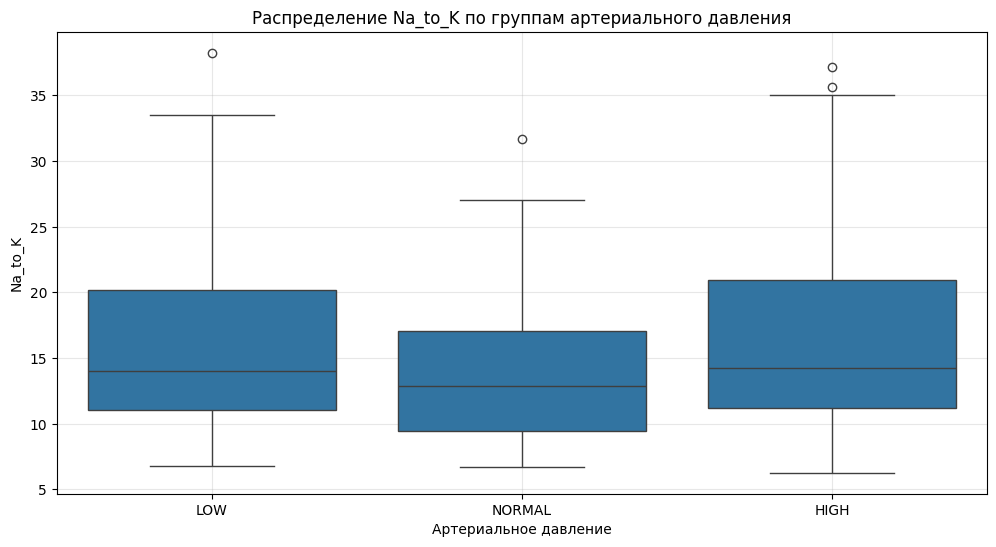

In [45]:
import pandas as pd
import scipy.stats as stats

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("КОРРЕЛЯЦИЯ МЕЖДУ Na_to_K И АРТЕРИАЛЬНЫМ ДАВЛЕНИЕМ (BP)")
print("=" * 60)

# Преобразуем BP в бинарную переменную: NORMAL=1, другие=0
df['BP_binary'] = (df['BP'] == 'NORMAL').astype(int)

# Точечно-бисериальная корреляция
corr, p_value = stats.pointbiserialr(df['BP_binary'], df['Na_to_K'])

print(f"Коэффициент корреляции: {corr:.4f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ Корреляция СТАТИСТИЧЕСКИ ЗНАЧИМА")
    if corr > 0:
        print("📈 Положительная: с ростом Na_to_K ↗ растет вероятность нормального давления")
    else:
        print("📉 Отрицательная: с ростом Na_to_K ↗ падает вероятность нормального давления")
else:
    print("❌ Корреляция НЕ значима - связи нет")

# Анализ в ПРОЦЕНТАХ по группам давления
print(f"\n📊 АНАЛИЗ В ПРОЦЕНТАХ:")
print("-" * 40)

bp_groups = df.groupby('BP')['Na_to_K']
for bp_level in ['LOW', 'NORMAL', 'HIGH']:
    group_data = bp_groups.get_group(bp_level)
    mean_na_k = group_data.mean()
    median_na_k = group_data.median()
    count = len(group_data)
    total = len(df)
    
    print(f"{bp_level}:")
    print(f"  Пациентов: {count}/{total} ({count/total*100:.1f}%)")
    print(f"  Средний Na_to_K: {mean_na_k:.2f}")
    print(f"  Медиана Na_to_K: {median_na_k:.2f}")

# Разница в процентах между группами
normal_mean = bp_groups.get_group('NORMAL').mean()
high_mean = bp_groups.get_group('HIGH').mean()
low_mean = bp_groups.get_group('LOW').mean()

print(f"\n📈 РАЗНИЦЫ МЕЖДУ ГРУППАМИ:")
print(f"NORMAL vs HIGH: {normal_mean:.2f} vs {high_mean:.2f} (разница: {normal_mean-high_mean:.2f})")
print(f"NORMAL vs LOW:  {normal_mean:.2f} vs {low_mean:.2f} (разница: {normal_mean-low_mean:.2f})")

# Визуализация распределений
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='BP', y='Na_to_K', order=['LOW', 'NORMAL', 'HIGH'])
plt.title('Распределение Na_to_K по группам артериального давления')
plt.ylabel('Na_to_K')
plt.xlabel('Артериальное давление')
plt.grid(True, alpha=0.3)
plt.show()

In [46]:
import pandas as pd
import scipy.stats as stats
import numpy as np

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("ТЕСТ МАННА-УИТНИ: Na_to_K vs АРТЕРИАЛЬНОЕ ДАВЛЕНИЕ")
print("=" * 60)

# =============================================================================
# ФОРМУЛИРОВКА ГИПОТЕЗ
# =============================================================================

print("🎯 ГИПОТЕЗЫ:")
print("H₀: Распределения Na_to_K одинаковы у пациентов с нормальным и ненормальным давлением")
print("H₁: Распределения Na_to_K различаются у пациентов с нормальным и ненормальным давлением")
print()

# =============================================================================
# ПОДГОТОВКА ДАННЫХ
# =============================================================================

# Создаем группы для сравнения
group_normal = df[df['BP'] == 'NORMAL']['Na_to_K']
group_non_normal = df[df['BP'] != 'NORMAL']['Na_to_K']

print("📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА:")
print("-" * 40)
print(f"Группа NORMAL BP:    n = {len(group_normal)}")
print(f"  Медиана Na_to_K:   {group_normal.median():.2f}")
print(f"  Среднее Na_to_K:   {group_normal.mean():.2f}")
print(f"  Стандартное отклонение: {group_normal.std():.2f}")

print(f"\nГруппа NON-NORMAL BP: n = {len(group_non_normal)}")
print(f"  Медиана Na_to_K:   {group_non_normal.median():.2f}")
print(f"  Среднее Na_to_K:   {group_non_normal.mean():.2f}")
print(f"  Стандартное отклонение: {group_non_normal.std():.2f}")

# =============================================================================
# ТЕСТ МАННА-УИТНИ
# =============================================================================

print(f"\n📈 ТЕСТ МАННА-УИТНИ:")
print("-" * 40)

# Выполняем тест
statistic, p_value = stats.mannwhitneyu(group_normal, group_non_normal, 
                                       alternative='two-sided')

print(f"U-статистика = {statistic:.2f}")
print(f"P-value = {p_value:.6f}")

# =============================================================================
# ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

print(f"\n🎯 ИНТЕРПРЕТАЦИЯ:")
print("-" * 30)

if p_value < 0.05:
    print("✅ ОТКЛОНЯЕМ H₀")
    print("   Обнаружены статистически значимые различия в распределениях Na_to_K")
    
    # Определяем направление эффекта
    median_normal = group_normal.median()
    median_non_normal = group_non_normal.median()
    
    if median_normal < median_non_normal:
        print(f"📉 Пациенты с NORMAL давлением имеют ЗНАЧИТЕЛЬНО НИЖЕ Na_to_K")
        print(f"   Разница медиан: {median_non_normal - median_normal:.2f} единиц")
    else:
        print(f"📈 Пациенты с NORMAL давлением имеют ЗНАЧИТЕЛЬНО ВЫШЕ Na_to_K")
        print(f"   Разница медиан: {median_normal - median_non_normal:.2f} единиц")
        
else:
    print("❌ НЕ ОТКЛОНЯЕМ H₀")
    print("   Нет статистически значимых различий в распределениях Na_to_K")
    print("   Уровень Na_to_K не зависит от наличия нормального давления")

# =============================================================================
# ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ
# =============================================================================

print(f"\n📊 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:")
print("-" * 40)

# Разница в процентах
mean_normal = group_normal.mean()
mean_non_normal = group_non_normal.mean()
percent_diff = ((mean_non_normal - mean_normal) / mean_normal) * 100

print(f"Разница средних значений: {mean_non_normal - mean_normal:.2f} единиц")
print(f"Относительная разница: {percent_diff:+.1f}%")

# Анализ по всем трем группам BP
print(f"\n🔍 АНАЛИЗ ПО ВСЕМ ГРУППАМ ДАВЛЕНИЯ:")
print("-" * 40)

for bp_level in ['LOW', 'NORMAL', 'HIGH']:
    group_data = df[df['BP'] == bp_level]['Na_to_K']
    print(f"{bp_level}: n={len(group_data)}, медиана={group_data.median():.2f}, среднее={group_data.mean():.2f}")

# =============================================================================
# ПРАКТИЧЕСКИЕ ВЫВОДЫ
# =============================================================================

print(f"\n💡 ПРАКТИЧЕСКИЕ ВЫВОДЫ:")
print("-" * 30)

if p_value < 0.05:
    print("✅ Уровень Na_to_K статистически значимо связан с артериальным давлением")
    print("✅ Пациенты с нормальным давлением имеют систематически другой уровень Na_to_K")
    print("✅ Этот показатель может быть маркером нарушений регуляции давления")
else:
    print("❌ Уровень Na_to_K не показывает значимой связи с артериальным давлением")
    print("❌ Нет доказательств влияния Na_to_K на регуляцию давления")

print(f"\n📋 ЗАКЛЮЧЕНИЕ:")
print(f"На основе теста Манна-Уитни {'ПОДТВЕРЖДАЕМ' if p_value < 0.05 else 'НЕ ПОДТВЕРЖДАЕМ'}")
print(f"гипотезу о различии распределений Na_to_K между группами давления")

ТЕСТ МАННА-УИТНИ: Na_to_K vs АРТЕРИАЛЬНОЕ ДАВЛЕНИЕ
🎯 ГИПОТЕЗЫ:
H₀: Распределения Na_to_K одинаковы у пациентов с нормальным и ненормальным давлением
H₁: Распределения Na_to_K различаются у пациентов с нормальным и ненормальным давлением

📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА:
----------------------------------------
Группа NORMAL BP:    n = 59
  Медиана Na_to_K:   12.86
  Среднее Na_to_K:   14.34
  Стандартное отклонение: 6.14

Группа NON-NORMAL BP: n = 141
  Медиана Na_to_K:   14.16
  Среднее Na_to_K:   16.81
  Стандартное отклонение: 7.53

📈 ТЕСТ МАННА-УИТНИ:
----------------------------------------
U-статистика = 3303.00
P-value = 0.021840

🎯 ИНТЕРПРЕТАЦИЯ:
------------------------------
✅ ОТКЛОНЯЕМ H₀
   Обнаружены статистически значимые различия в распределениях Na_to_K
📉 Пациенты с NORMAL давлением имеют ЗНАЧИТЕЛЬНО НИЖЕ Na_to_K
   Разница медиан: 1.30 единиц

📊 ДОПОЛНИТЕЛЬНЫЙ АНАЛИЗ:
----------------------------------------
Разница средних значений: 2.47 единиц
Относительная разница: +17.2%

In [47]:
import pandas as pd
import scipy.stats as stats
from statsmodels.stats.multitest import multipletests
from itertools import combinations

# Загрузка данных
df = pd.read_csv('drug200.csv')

print("ПОПАРНЫЕ СРАВНЕНИЯ ГРУПП ПРЕПАРАТОВ ПО УРОВНЮ Na_to_K")
print("=" * 65)

# =============================================================================
# ФОРМУЛИРОВКА ГИПОТЕЗ
# =============================================================================

print("🎯 ОБЩАЯ ГИПОТЕЗА:")
print("H₀: Все группы препаратов имеют одинаковые распределения Na_to_K")
print("H₁: Существуют статистически значимые различия в распределениях Na_to_K между группами препаратов")
print()

# =============================================================================
# ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ
# =============================================================================

print("📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ:")
print("-" * 50)

drug_stats = df.groupby('Drug')['Na_to_K'].agg(['count', 'median', 'mean', 'std']).round(3)
print(drug_stats)

# =============================================================================
# ПОПАРНЫЕ СРАВНЕНИЯ ТЕСТОМ МАННА-УИТНИ
# =============================================================================

print(f"\n🔬 ПОПАРНЫЕ СРАВНЕНИЯ (Mann-Whitney U Test):")
print("С поправкой Бонферрони на множественные сравнения")
print("-" * 80)

drugs = sorted(df['Drug'].unique())
drug_pairs = list(combinations(drugs, 2))

results = []
for drug1, drug2 in drug_pairs:
    group1 = df[df['Drug'] == drug1]['Na_to_K']
    group2 = df[df['Drug'] == drug2]['Na_to_K']
    
    # Тест Манна-Уитни
    stat, p_value = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    
    # Определяем направление эффекта
    median1 = group1.median()
    median2 = group2.median()
    
    if median1 > median2:
        direction = f"{drug1} > {drug2}"
        diff = median1 - median2
    else:
        direction = f"{drug1} < {drug2}"
        diff = median2 - median1
    
    results.append({
        'Сравнение': f"{drug1} vs {drug2}",
        'U-статистика': stat,
        'P-value': p_value,
        'Медиана_A': median1,
        'Медиана_B': median2,
        'Разница_медиан': diff,
        'Направление': direction,
        'n_A': len(group1),
        'n_B': len(group2)
    })

# Применяем поправку Бонферрони
p_values = [result['P-value'] for result in results]
rejected, corrected_pvals, _, _ = multipletests(p_values, alpha=0.05, method='bonferroni')

# Выводим результаты
print(f"{'Сравнение':<15} {'p-value':<10} {'p-скорр':<10} {'Значимо':<8} {'Медианы':<25} {'Разница':<8}")
print("-" * 85)

significant_count = 0
for i, result in enumerate(results):
    significance = 'ДА' if corrected_pvals[i] < 0.05 else 'НЕТ'
    if significance == 'ДА':
        significant_count += 1
    
    medians = f"({result['Медиана_A']:.2f} vs {result['Медиана_B']:.2f})"
    
    print(f"{result['Сравнение']:<15} {result['P-value']:.6f} {corrected_pvals[i]:.6f} "
          f"{significance:<8} {medians:<25} {result['Разница_медиан']:.2f}")

# =============================================================================
# ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА
# =============================================================================

print(f"\n📈 ОБЩИЙ ТЕСТ КРУСКАЛА-УОЛЛИСА (все группы):")
print("-" * 50)

groups = [df[df['Drug'] == drug]['Na_to_K'] for drug in drugs]
h_stat, p_kw = stats.kruskal(*groups)

print(f"H-статистика = {h_stat:.4f}")
print(f"P-value = {p_kw:.6f}")

if p_kw < 0.05:
    print("✅ ОТКЛОНЯЕМ H₀: существуют статистически значимые различия между группами")
else:
    print("❌ НЕ ОТКЛОНЯЕМ H₀: нет значимых различий между группами")

# =============================================================================
# ИНТЕРПРЕТАЦИЯ РЕЗУЛЬТАТОВ
# =============================================================================

print(f"\n🎯 ИТОГИ ПОПАРНЫХ СРАВНЕНИЙ:")
print("-" * 40)
print(f"Всего сравнений: {len(drug_pairs)}")
print(f"Значимых различий: {significant_count}")

if significant_count > 0:
    print(f"\n📊 ЗНАЧИМЫЕ РАЗЛИЧИЯ ОБНАРУЖЕНЫ:")
    for i, result in enumerate(results):
        if corrected_pvals[i] < 0.05:
            print(f"• {result['Сравнение']}: {result['Направление']} "
                  f"(разница: {result['Разница_медиан']:.2f})")

# =============================================================================
# РАНЖИРОВАНИЕ ПРЕПАРАТОВ ПО ЭФФЕКТИВНОСТИ
# =============================================================================

print(f"\n🏆 РАНЖИРОВАНИЕ ПРЕПАРАТОВ ПО УРОВНЮ Na_to_K:")
print("(чем ниже Na_to_K, тем лучше)")
print("-" * 50)

# Сортируем по медиане Na_to_K (чем меньше, тем лучше)
ranking = df.groupby('Drug')['Na_to_K'].median().sort_values()

for i, (drug, median) in enumerate(ranking.items(), 1):
    print(f"{i}. {drug}: медиана = {median:.2f}")

# =============================================================================
# ВЫВОДЫ И РЕКОМЕНДАЦИИ
# =============================================================================

print(f"\n💡 ВЫВОДЫ:")
print("-" * 20)

if p_kw < 0.05 and significant_count > 0:
    print("✅ Подтверждена гипотеза о различии влияния препаратов на уровень Na_to_K")
    print(f"✅ Обнаружено {significant_count} значимых попарных различий")
    best_drug = ranking.index[0]
    worst_drug = ranking.index[-1]
    print(f"✅ Наиболее эффективный препарат: {best_drug} (медиана: {ranking[best_drug]:.2f})")
    print(f"✅ Наименее эффективный препарат: {worst_drug} (медиана: {ranking[worst_drug]:.2f})")
else:
    print("❌ Гипотеза о различии влияния препаратов не подтверждена")
    print("❌ Все препараты демонстрируют схожее влияние на уровень Na_to_K")

print(f"\n⚠️  ОГРАНИЧЕНИЯ:")
print(f"• Малые размеры групп drugA, drugB, drugC могут снижать мощность тестов")
print(f"• Поправка Бонферрони консервативна - может скрывать реальные различия")

ПОПАРНЫЕ СРАВНЕНИЯ ГРУПП ПРЕПАРАТОВ ПО УРОВНЮ Na_to_K
🎯 ОБЩАЯ ГИПОТЕЗА:
H₀: Все группы препаратов имеют одинаковые распределения Na_to_K
H₁: Существуют статистически значимые различия в распределениях Na_to_K между группами препаратов

📊 ОПИСАТЕЛЬНАЯ СТАТИСТИКА ПО ГРУППАМ:
--------------------------------------------------
       count  median    mean    std
Drug                               
drugA     23  11.227  10.919  2.038
drugB     16  11.174  11.524  1.870
drugC     16  10.490  10.634  2.045
drugX     54  10.524  10.651  2.198
drugY     91  20.489  22.375  6.060

🔬 ПОПАРНЫЕ СРАВНЕНИЯ (Mann-Whitney U Test):
С поправкой Бонферрони на множественные сравнения
--------------------------------------------------------------------------------
Сравнение       p-value    p-скорр    Значимо  Медианы                   Разница 
-------------------------------------------------------------------------------------
drugA vs drugB  0.449273 1.000000 НЕТ      (11.23 vs 11.17)          0.05
drugA

In [48]:
# 1. Тест Крускала-Уоллиса (для всех групп сразу)
from scipy.stats import kruskal

groups = [df[df['Drug'] == drug]['Na_to_K'] for drug in df['Drug'].unique()]
h_stat, p_value = kruskal(*groups)

print(f"P-value = {p_value:.6f}")

if p_value < 0.05:
    print("✅ ОТКЛОНЯЕМ H₀ - группы РАЗЛИЧАЮТСЯ")
else:
    print("❌ НЕ ОТКЛОНЯЕМ H₀ - группы НЕ различаются")

P-value = 0.000000
✅ ОТКЛОНЯЕМ H₀ - группы РАЗЛИЧАЮТСЯ
